# Perturbative and numerical study of nonlinear relativistic effects in weak lensing
## M. Magi, F. Lepori, J.Adamek

This Notebook reproduces all the figures displayed in the paper.

Author: F. Lepori

In [1]:
"""
Read simulated power spectra at source redshift zm = 0.5, 1.0
and store them in a dictionary for easier access
"""

import numpy as np

def load_spectra(zm, suffix):
    file_path = (
        f"sim-data/"
        f"Spectra_nside16384_downgradeto8192_z{zm}_{suffix}.dat"
    )
    return np.loadtxt(file_path)


def shear_factor(ell):
    """
    (l+2)(l-1) / [l(l+1)] with l < 2 safely excluded
    """
    fact = np.zeros_like(ell, dtype=float)
    valid = ell >= 2
    fact[valid] = (
        (ell[valid] + 2)
        * (ell[valid] - 1)
        / (ell[valid] * (ell[valid] + 1))
    )
    return fact


spectra = {}

for zm in [0.5, 1.0]:
    spectra[zm] = {}

    # ---------- Includes both scalar and vector perturbations ----------
    data = load_spectra(zm, "full")
    ell = data[:, 0]
    spectra[zm]["ell"] = data[:, 0]
    spectra[zm]["cl_kappa"] = data[:, 1]
    spectra[zm]["cl_omega"] = data[:, 2]
    spectra[zm]["cl_eps1"] = data[:, 3]
    spectra[zm]["cl_eps2"] = data[:, 4]
    spectra[zm]["cl_shear1"] = data[:, 5]
    spectra[zm]["cl_shear2"] = data[:, 6]

    # ---------- Includes only vector perturbations ----------
    data = load_spectra(zm, "onlyB")
    ell_B = data[:, 0]
    spectra[zm]["ell_B"] = data[:, 0]
    spectra[zm]["cl_kappa_B"] = data[:, 1]
    spectra[zm]["cl_omega_B"] = data[:, 2]
    spectra[zm]["cl_eps1_B"] = data[:, 3]
    spectra[zm]["cl_eps2_B"] = data[:, 4]
    spectra[zm]["cl_shear1_B"] = data[:, 5]
    spectra[zm]["cl_shear2_B"] = data[:, 6]

    # ---------- Includes only scalar perturbations ----------
    data = load_spectra(zm, "noB")
    ell_noB = data[:, 0] 
    spectra[zm]["ell_noB"] = data[:, 0]
    spectra[zm]["cl_kappa_noB"] = data[:, 1]
    spectra[zm]["cl_omega_noB"] = data[:, 2]
    spectra[zm]["cl_eps1_noB"] = data[:, 3]
    spectra[zm]["cl_eps2_noB"] = data[:, 4]
    spectra[zm]["cl_shear1_noB"] = data[:, 5]
    spectra[zm]["cl_shear2_noB"] = data[:, 6]

    # ---------- Includes both scalar and vector perturbations (deflection angle approximation) ----------
    data = load_spectra(zm, "full_deflection")
    ell_def = data[:, 0]
    fact = shear_factor(ell_def)

    spectra[zm]["ell_def"] = ell_def
    spectra[zm]["cl_kappa_def"] = data[:, 1]
    spectra[zm]["cl_omega_def"] = data[:, 2]
    spectra[zm]["cl_shear1_def"] = data[:, 3] * fact
    spectra[zm]["cl_shear2_def"] = data[:, 4] * fact

    # ---------- Includes only scalar perturbations (deflection angle approximation) ----------
    data = load_spectra(zm, "noB_deflection")
    ell_noB_def = data[:, 0]
    fact = shear_factor(ell_noB_def)

    spectra[zm]["ell_noB_def"] = ell_noB_def
    spectra[zm]["cl_kappa_noB_def"] = data[:, 1]
    spectra[zm]["cl_omega_noB_def"] = data[:, 2]
    spectra[zm]["cl_shear1_noB_def"] = data[:, 3] * fact
    spectra[zm]["cl_shear2_noB_def"] = data[:, 4] * fact

    # ---------- Includes only vector perturbations (deflection angle approximation) ----------
    data = load_spectra(zm, "onlyB_deflection")
    ell_B_def = data[:, 0]
    fact = shear_factor(ell_B_def)

    spectra[zm]["ell_B_def"] = ell_B_def
    spectra[zm]["cl_kappa_B_def"] = data[:, 1]
    spectra[zm]["cl_omega_B_def"] = data[:, 2]
    spectra[zm]["cl_shear1_B_def"] = data[:, 3] * fact
    spectra[zm]["cl_shear2_B_def"] = data[:, 4] * fact



# Scalar-induced power spectra

In [2]:
"""
We use some routines from CAMB to compute the theoretical field rotation power spectrum and 
the convergence power spectrum.
Parts of these routines are adapted from the CAMB code (Code for Anisotropies in the Microwave Background),
developed by Antony Lewis and Anthony Challinor.
CAMB website: https://camb.info
"""

import camb
from camb import model
import numpy as np
import time

from scipy.interpolate import RectBivariateSpline, InterpolatedUnivariateSpline

def cl_kappa_limber(results, PK, ls, nz, chi_source, setting='use_z_snap', z_snap = 0.25, chi_source2=None):
    """
    Modified CAMB routine to compute the convergence power spectrum in the standard weak-lensing formalism. It uses the Limber approximation.
    """
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win = (1 / chis - 1 / chi_source) * (1 / chis - 1 / chi_source2) / chis ** 2
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'use_z_snap': # we evaluate the power spectrum of the Weyl potential at a fixed redshift
            cl[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win / k ** 4)
        else: # correct expression 
            cl[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win / k ** 4) 
    cl *= (ls * (ls + 1)) ** 2 # Here they use the full sky expression
    return cl

def get_field_rotation_power(params, kmax=100, lmax=20000, setting='use_z_snap', z_snap = 0.25, non_linear=True, z_source=None,
                             k_per_logint=None, acc=1, lsamp=None):
    """
    Modified CAMB routine to compute the theoretical field rotation power spectrum.
    The routine implementation follow the theoretical derivation in  arXiv:1605.05662. Uses the lowest Limber approximation.
    """

    results = camb.get_background(params)
    if z_source:
        chi_source = results.comoving_radial_distance(z_source)
    else:
        chi_source = results.tau0 - results.tau_maxvis
        z_source = results.redshift_at_comoving_radial_distance(chi_source)

    PK = camb.get_matter_power_interpolator(params, nonlinear=non_linear,
                                            hubble_units=False, k_hunit=False, kmax=kmax, k_per_logint=k_per_logint,
                                            var1=model.Transfer_Weyl, var2=model.Transfer_Weyl, zmax=z_source)
    return get_field_rotation_power_from_PK(params, PK, chi_source, setting, z_snap, lmax, acc, lsamp)


def get_field_rotation_power_from_PK(params, PK, chi_source, setting='use_z_snap', z_snap = 0.25,lmax=20000, acc=1, lsamp=None):
    results = camb.get_background(params)
    nz = int(100 * acc)
    if lmax < 3000:
        raise ValueError('field rotation assumed lmax > 3000')
    ls = np.hstack((np.arange(2, 400, 1), np.arange(401, 2600, int(10. / acc)),
                    np.arange(2650, lmax, int(50. / acc)), np.arange(lmax, lmax + 1))).astype(np.float64)

    # get grid of C_L(chi_s,k) for different redshifts
    chimaxs = np.linspace(0, chi_source, nz)
    cls = np.zeros((nz, ls.size))
    for i, chimax in enumerate(chimaxs[1:]):
        cl = cl_kappa_limber(results, PK, ls, nz, chimax, setting, z_snap)
        cls[i + 1, :] = cl
    cls[0, :] = 0
    cl_chi = RectBivariateSpline(chimaxs, ls, cls) # interpolation function for the convergence power spectrum in (chi_s,k)
    # Get M(L,L') matrix
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2 
    chis = chis[1:-1] 
    zs = zs[1:-1]     
    win = (1 / chis - 1 / chi_source) ** 2 / chis ** 2  #window function
    w = np.ones(chis.shape)
    cchi = cl_chi(chis, ls, grid=True)
    M = np.zeros((ls.size, ls.size))
    for i, ell in enumerate(ls):
        k = (ell + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'use_z_snap':
            cl = np.dot(dchis * w * PK.P(z_snap, k, grid=False) * win / k ** 4, cchi)
        else:
            cl = np.dot(dchis * w * PK.P(zs, k, grid=False) * win / k ** 4, cchi)
        M[i, :] = cl * ell ** 4  
    Mf = RectBivariateSpline(ls, ls, np.log(M)) # interpolation function for log(M(L,L'))

    # L sampling for output
    if lsamp is None:
        lsamp = np.hstack((np.arange(2, 20, 2), np.arange(25, 200, 10 // acc), np.arange(220, 1200, 30 // acc),
                           np.arange(1300, min(lmax // 2, 2600), 150 // acc),
                           np.arange(3000, lmax // 2 + 1, 1000 // acc)))

    # Get field rotation (curl) spectrum.
    diagm = np.diag(M)
    diagmsp = InterpolatedUnivariateSpline(ls, diagm)

    def high_curl_integrand(_ll, _lp):
        _lp = _lp.astype(int)
        r2 = (np.float64(_ll) / _lp) ** 2
        return _lp * r2 * diagmsp(_lp) / np.pi

    clcurl = np.zeros(lsamp.shape)
    lsall = np.arange(2, lmax + 1, dtype=np.float64)

    for i, ll in enumerate(lsamp):

        ell = np.float64(ll)
        lmin = lsall[0]
        lpmax = min(lmax, int(max(1000, ell * 2)))
        if ll < 500:
            lcalc = lsall[0:lpmax - 2]
        else:
            # sampling in L', with denser around L~L'
            lcalc = np.hstack((lsall[0:20:4],
                               lsall[29:ll - 200:35],
                               lsall[ll - 190:ll + 210:6],
                               lsall[ll + 220:lpmax + 60:60]))

        tmps = np.zeros(lcalc.shape)
        for ix, lp in enumerate(lcalc):
            llp = int(lp)
            lp = np.float64(lp)
            if abs(ll - llp) > 200 and lp > 200:
                nphi = 2 * int(min(lp / 10 * acc, 200)) + 1
            elif ll > 2000:
                nphi = 2 * int(lp / 10 * acc) + 1
            else:
                nphi = 2 * int(lp) + 1
            dphi = 2 * np.pi / nphi
            phi = np.linspace(dphi, (nphi - 1) / 2 * dphi, (nphi - 1) // 2)  # even and don't need zero
            w = 2 * np.ones(phi.size)
            cosphi = np.cos(phi)
            lrat = lp / ell
            lfact = np.sqrt(1 + lrat ** 2 - 2 * cosphi * lrat)
            lnorm = ell * lfact # /l - L/
            lfact[lfact <= 0] = 1
            w[lnorm < lmin] = 0
            w[lnorm > lmax] = 0

            lnorm = np.maximum(lmin, np.minimum(lmax, lnorm))
            tmps[ix] += lp * np.dot(w, (np.sin(phi) / lfact ** 2 * (cosphi - lrat)) ** 2 *
                                    np.exp(Mf(lnorm, lp, grid=False))) * dphi

        sp = InterpolatedUnivariateSpline(lcalc, tmps)
        clcurl[i] = sp.integral(2, lpmax - 1) * 4 / (2 * np.pi) ** 2

        if lpmax < lmax:
            tail = np.sum(high_curl_integrand(ll, lsall[lpmax - 2:]))
            clcurl[i] += tail

    return lsamp, clcurl

#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()

A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

pars.set_cosmology(H0=100.0*h, ombh2=Omega_b*h*h, omch2=Omega_cdm*h*h, TCMB = T_cmb, omk=0, tau=0.06)
camb.set_params(num_nu_massless = 1.01533, num_nu_massive = 2, nu_mass_eigenstates = 2, nu_mass_degeneracies = [1, 1], nu_mass_numbers = [1, 1], nu_mass_fractions = [0.1481, 0.8519], share_delta_neff = True) 
pars.InitPower.set_params(As=A_s, ns=n_s, r=0)
pars.set_for_lmax(3500, lens_potential_accuracy=0);

zm = 0.5
zm1 = 1.0

start = time.time()

l, cl_omom = get_field_rotation_power(pars, kmax=100, lmax=5000, setting = 'use_z_snap', z_snap = 0.25, non_linear=True, z_source=zm,
                             k_per_logint=None, acc=3, lsamp=None)
elapsed = time.time() - start
print('Rotation power spectrum computed at z = 0.5.')
print(f"Computation finished in {elapsed:.2f} seconds")

start = time.time()

l_z1, cl_omom_z1 = get_field_rotation_power(pars, kmax=100, lmax=5000, setting = 'use_z_snap', z_snap = 0.25, non_linear=True, z_source=zm1,
                             k_per_logint=None, acc=3, lsamp=None)
elapsed = time.time() - start
print('Rotation power spectrum computed at z = 1.')
print(f"Computation finished in {elapsed:.2f} seconds")

Rotation power spectrum computed at z = 0.5.
Computation finished in 82.35 seconds
Rotation power spectrum computed at z = 1.
Computation finished in 78.31 seconds


In [3]:
"""
Scalar-induced convergence in the standard weak-lensing formalism
"""
zm = 0.5
zm1 = 1.0
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(zm)
chi_source_z1 = results.comoving_radial_distance(zm1)

lmax = 1000
acc = 3.0
nz = int(100 * acc)

lsamp_vec = np.hstack((np.arange(2, 10, 1), np.arange(11, 100, 4),
                    np.arange(101, lmax, 25))).astype(np.float64)

start = time.time()

PK = camb.get_matter_power_interpolator(
    pars,
    nonlinear=True,
    hubble_units=False,
    k_hunit=False,
    kmax=100,
    var1=model.Transfer_Weyl,
    var2=model.Transfer_Weyl,
    zmax=zm1
)

cl_kappa_scalar_def = cl_kappa_limber(results, PK, lsamp_vec, nz, chi_source, setting='use_z_snap', z_snap = 0.25)
cl_kappa_scalar_def_z1 = cl_kappa_limber(results, PK, lsamp_vec, nz, chi_source_z1, setting='use_z_snap', z_snap = 0.25)
elapsed = time.time() - start
print('Convergence (standard weak-lensing formalism) power spectrum computed.')
print(f"Computation finished in {elapsed:.2f} seconds")

Convergence (standard weak-lensing formalism) power spectrum computed.
Computation finished in 2.44 seconds


In [4]:
"""
Modified CAMB routine to compute the convergence power spectrum including all the terms derived in our paper.
cl_gE_limber: computes the standard weak-lensing shear E-modes power spectrum. Up to an ell-dependent factor, coincides with cl_kappa_limber.
cl_kappa_rel: computes the full linear convergence power spectrum including all the relativistic terms derived in our paper.
"""
from scipy.integrate import simpson

def cl_gE_limber(results, PK, ls, nz, chi_source, setting='use_z_snap', z_snap = 0.25, chi_source2=None):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win = (1 / chis - 1 / chi_source) * (1 / chis - 1 / chi_source2) / chis ** 2
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'use_z_snap':
            cl[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win / k ** 4)
        else:
            cl[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win / k ** 4)
    cl *=  (ls * (ls + 1)) * (ls + 2) * (ls - 1) # Here they use the full sky expression
    return cl

def cl_kappa_rel(results, PK, ls, nz, chi_source, setting='use_z_snap', z_snap = 0.25, chi_source2=None):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win = (1 / chis - 1 / chi_source) * (1 / chis - 1 / chi_source2) / chis ** 2
    cl_gEE = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'use_z_snap':
            cl_gEE[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win / k ** 4)
        else:
            cl_gEE[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win / k ** 4)
    cl_gEE *= (ls * (ls + 1)) * (ls + 2) * (ls - 1)  # Here they use the full sky expression

    # ======================
    # T1: boundary term
    # ======================
    Hconf_s = results.h_of_z(z_source)/(1.0+z_source)
    T1 = np.zeros(ls.shape)
    for i, l in enumerate(ls):
        k_s = (l + 0.5) / chi_source
        ww= 1
        if k_s > PK.kmax:
            ww = 0
        if k_s < 1e-4:
            ww = 0
        if setting == 'use_z_snap':
            T1[i] = (-8.0 / chi_source**3 * (2.0 - 1.0 / (Hconf_s * chi_source)) * ww *  PK.P(z_snap, k_s, grid=False) / k_s**4)
        else:
            T1[i] = (-8.0 / chi_source**3 * (2.0 - 1.0 / (Hconf_s * chi_source)) * ww * PK.P(zs[-1], k_s, grid=False) / k_s**4)
    # ======================
    # T2: line-of-sight term
    # ======================
    T2a = np.zeros(ls.shape)
    T2b = np.zeros(ls.shape)
    win_t2_a = (1 / chis - 1 / chi_source) / chis ** 2
    win_t2_b = 2.0 / chis ** 2
    for i, l in enumerate(ls):
        k = (l + 0.5) / chis
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= PK.kmax] = 0
        if setting == 'use_z_snap':
            T2a[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win_t2_a / k ** 4)
            T2b[i] = np.dot(dchis, w * PK.P(z_snap, k, grid=False) * win_t2_b / k ** 4)
        else:
            T2a[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win_t2_a / k ** 4)
            T2b[i] = np.dot(dchis, w * PK.P(zs, k, grid=False) * win_t2_b / k ** 4)
    T2a *= 8.0/chi_source * ls**2 
    T2b *= 8.0/chi_source**2
    # ======================
    # T3: longitudinal modes
    # ======================
    T3 = np.zeros(ls.shape)
    # Precompute k_parallel grid 
    k_par = np.logspace(-6, np.log10(PK.kmax), 1500)
    k_par2 = k_par**2

    for i, l in enumerate(ls):
        k_perp2 = (l / chi_source)**2
        k = np.sqrt(k_perp2 + k_par2)

        if setting == 'True':
            Pk = PK.P(zs, k, grid=False)
        else:
            Pk = PK.P(z_snap, k, grid=False)
        integrand = Pk / k**4

        T3[i] = simpson(integrand, x=k_par)

    T3 *= (2.0 - 1.0 / (Hconf_s * chi_source))**2 / chi_source**2 / np.pi

    return cl_gEE + T1 + T2a + T2b + T3, T1, T2a + T2b, T3

z_source = 0.5
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

lmax = 1000
acc = 3.0
nz = int(100 * acc)

lsamp_vec = np.hstack((np.arange(2, 10, 1), np.arange(11, 100, 4),
                    np.arange(101, lmax, 25))).astype(np.float64)

start = time.time()

PK = camb.get_matter_power_interpolator(
    pars,
    nonlinear=True,
    hubble_units=False,
    k_hunit=False,
    kmax=100,
    var1=model.Transfer_Weyl,
    var2=model.Transfer_Weyl,
    zmax=zm1
)

cl_gammaE = cl_gE_limber(results, PK, lsamp_vec, nz, chi_source, setting='use_z_snap', z_snap = 0.25)
cl_kappa, T1, T2, T3 = cl_kappa_rel(results, PK, lsamp_vec, nz, chi_source, setting='use_z_snap', z_snap = 0.25)

z_source = 1.0
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

cl_gammaE_z1 = cl_gE_limber(results, PK, lsamp_vec, nz, chi_source, setting='use_z_snap', z_snap = 0.25)
elapsed = time.time() - start
print('Convergence power spectrum (with relativistic effects) computed.')
print(f"Computation finished in {elapsed:.2f} seconds")


Convergence power spectrum (with relativistic effects) computed.
Computation finished in 2.45 seconds


In [5]:
import matplotlib.pyplot as plt
from glob import glob as gl

from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator

plt.rcParams['figure.dpi'] = 400
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = ['Verdana']
plt.rcParams['legend.edgecolor'] = '0.0'
plt.rcParams['figure.figsize'] = 4, 12.0/5.0 
#plt.rcParams.update({'figure.autolayout': True})
plt.rcParams['text.usetex'] = True

def tol_cset(colorset=None):
    """
    Discrete color sets for qualitative data.

    Define a namedtuple instance with the colors.
    Examples for: cset = tol_cset(<scheme>)
      - cset.red and cset[1] give the same color (in default 'bright' colorset)
      - cset._fields gives a tuple with all color names
      - list(cset) gives a list with all colors
    """
    from collections import namedtuple
    
    namelist = ('bright', 'high-contrast', 'vibrant', 'muted', 'medium-contrast', 'light')
    if colorset is None:
        return namelist
    if colorset not in namelist:
        colorset = 'bright'
        print('*** Warning: requested colorset not defined,',
              'known colorsets are {}.'.format(namelist),
              'Using {}.'.format(colorset)) 

    if colorset == 'bright':
        cset = namedtuple('Bcset',
                    'blue red green yellow cyan purple grey black')
        return cset('#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE',
                    '#AA3377', '#BBBBBB', '#000000')

    if colorset == 'high-contrast':
        cset = namedtuple('Hcset',
                    'blue yellow red black')
        return cset('#004488', '#DDAA33', '#BB5566', '#000000')

    if colorset == 'vibrant':
        cset = namedtuple('Vcset',
                    'orange blue cyan magenta red teal grey black')
        return cset('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311',
                    '#009988', '#BBBBBB', '#000000')

    if colorset == 'muted':
        cset = namedtuple('Mcset',
                    'rose indigo sand green cyan wine teal olive purple pale_grey black')
        return cset('#CC6677', '#332288', '#DDCC77', '#117733', '#88CCEE',
                    '#882255', '#44AA99', '#999933', '#AA4499', '#DDDDDD',
                    '#000000')

    if colorset == 'medium-contrast':
        cset = namedtuple('Mcset',
                    'light_blue dark_blue light_yellow dark_red dark_yellow light_red black')
        return cset('#6699CC', '#004488', '#EECC66', '#994455', '#997700',
                    '#EE99AA', '#000000')

    if colorset == 'light':
        cset = namedtuple('Lcset',
                    'light_blue orange light_yellow pink light_cyan mint pear olive pale_grey black')
        return cset('#77AADD', '#EE8866', '#EEDD88', '#FFAABB', '#99DDFF',
                    '#44BB99', '#BBCC33', '#AAAA00', '#DDDDDD', '#000000')
    
cset = tol_cset("bright")

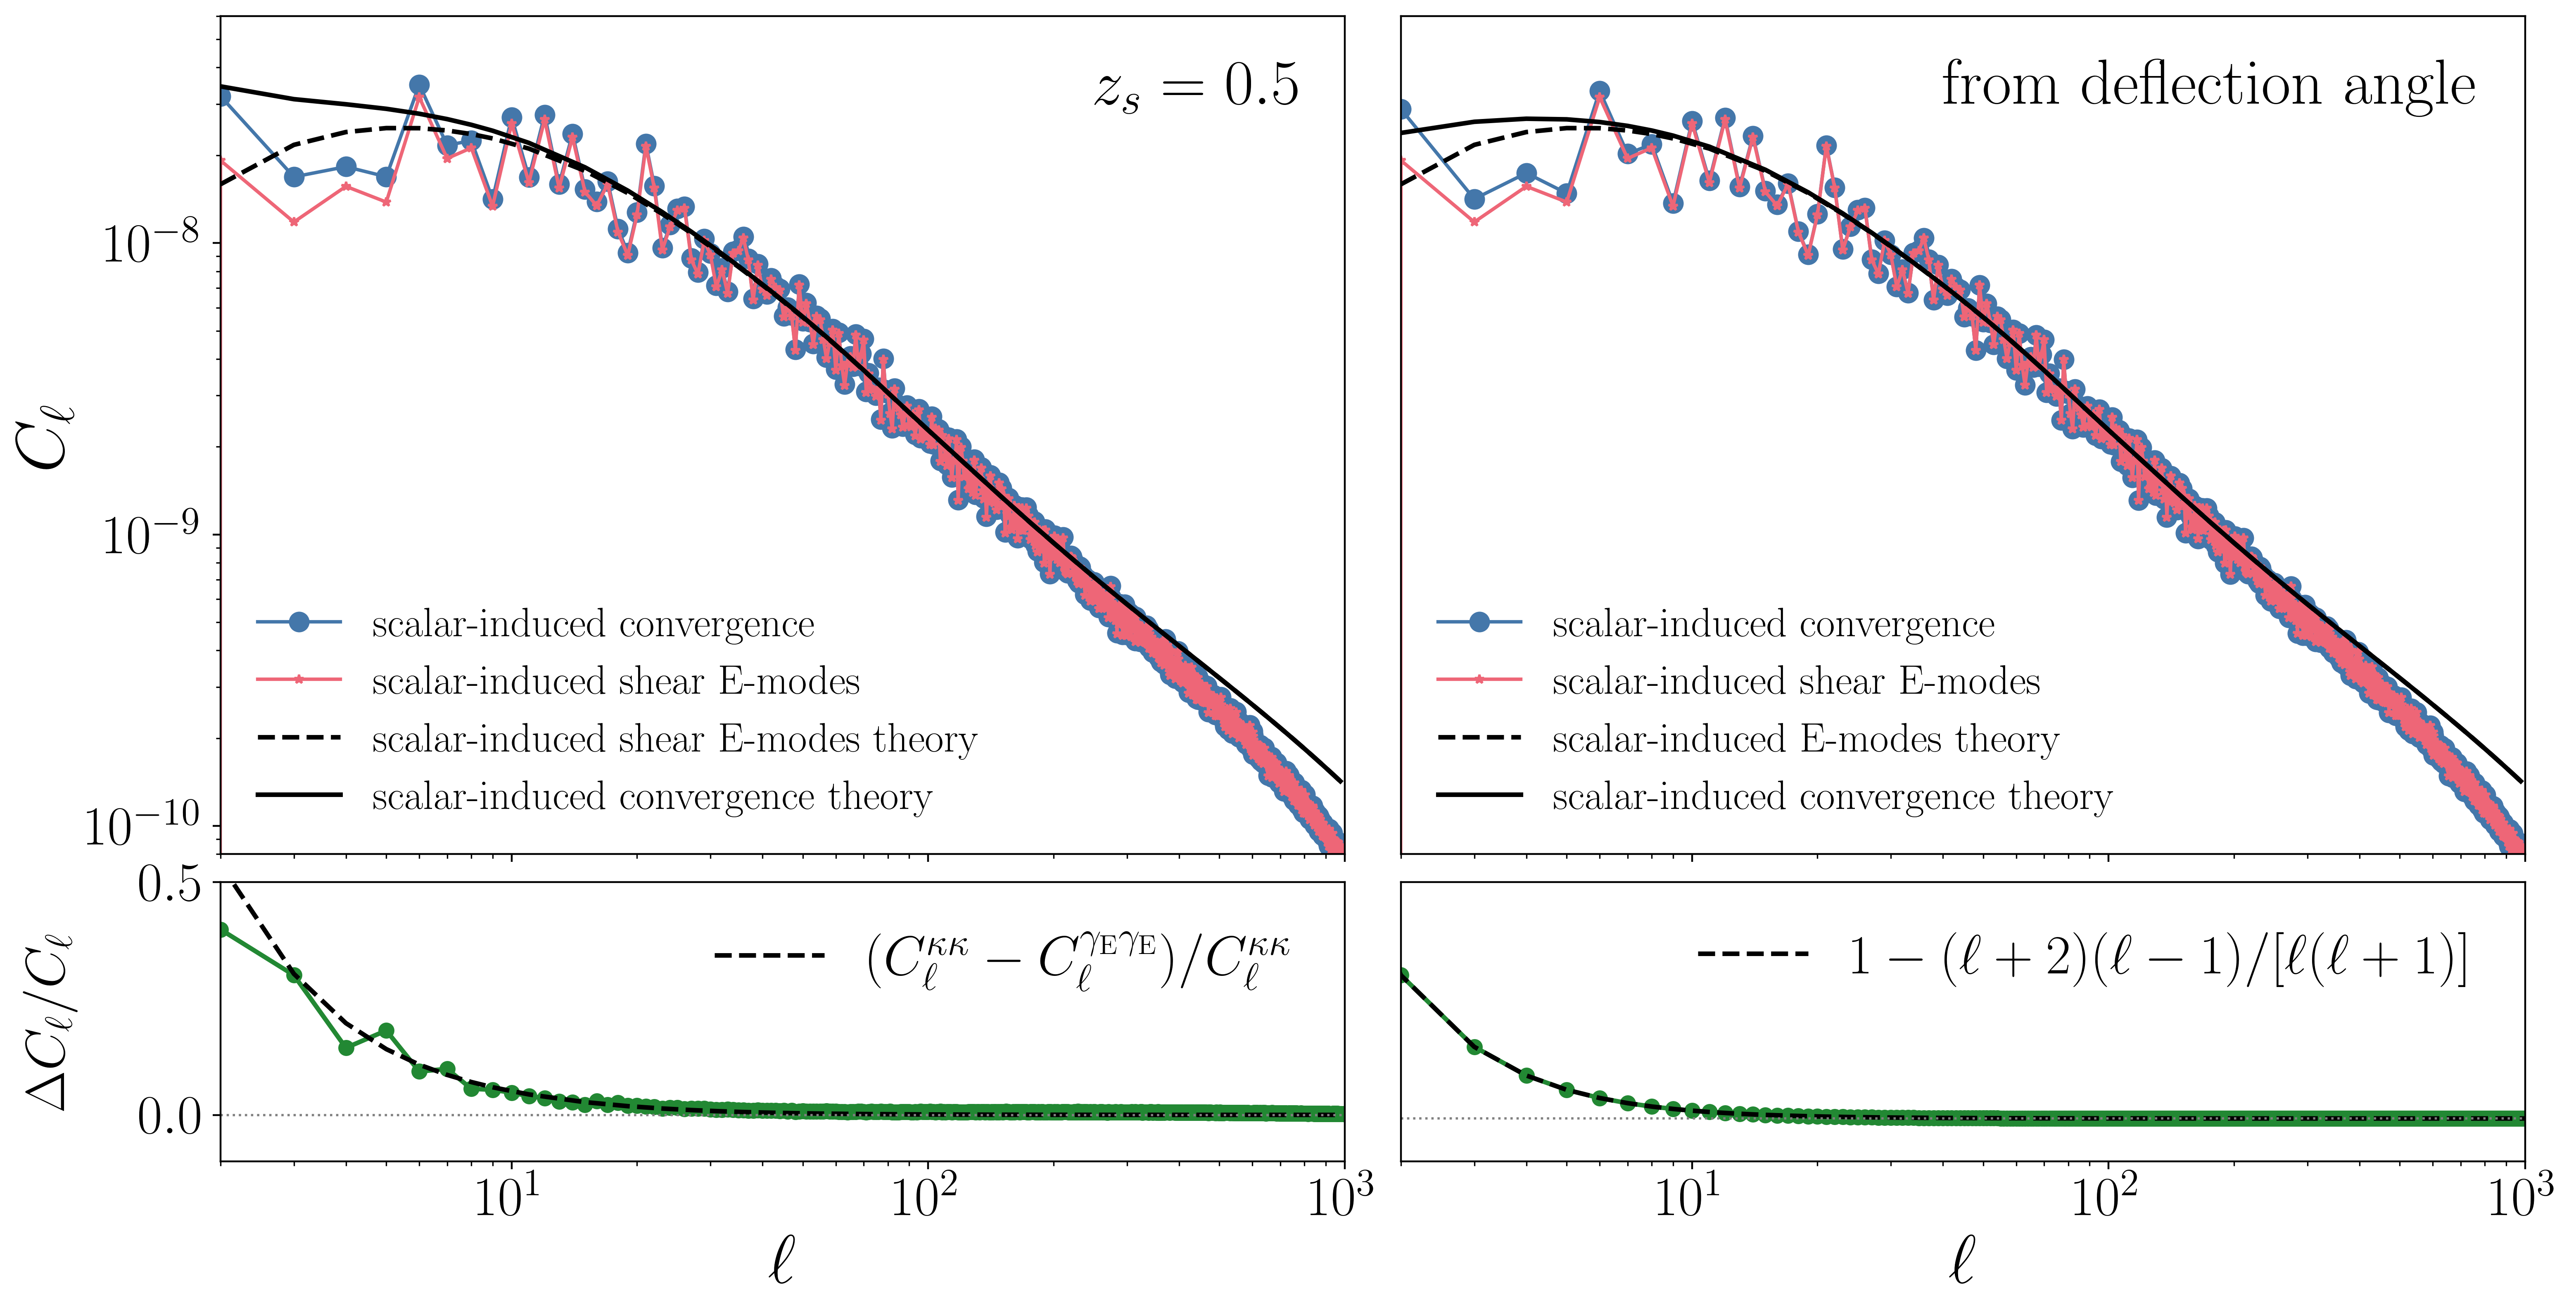

done


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams['mathtext.fontset'] = 'cm'

# =========================================================
# Fig. 2
# =========================================================

fig = plt.figure(figsize=(18, 9))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0.05,
    wspace=0.05
)

z_plot = 0.5
# ---- Top left
ax11 = fig.add_subplot(gs[0, 0])

ax11.plot(ell_noB, spectra[z_plot]['cl_kappa_noB'],
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced convergence')

ax11.plot(ell_noB, spectra[z_plot]['cl_shear1_noB'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced shear E-modes')

ax11.plot(lsamp_vec, cl_gammaE,
         ls='--', lw=2, color='k',
         label=r'scalar-induced shear E-modes theory')

ax11.plot(lsamp_vec, cl_kappa,
         ls='-', lw=2, color='k',
         label=r'scalar-induced convergence theory')

ax11.set_xscale('log')
ax11.set_yscale('log')
ax11.set_ylim([8e-11, 6e-8])
ax11.set_xlim([2, 1000])

ax11.set_ylabel(r'$C_{\ell}$', fontsize=30)
ax11.legend(loc="lower left", fontsize=18, frameon=False)

ax11.tick_params(axis='y', labelsize=24)
ax11.tick_params(axis='x', labelbottom=False)

ax11.text(250, 3e-8, r'$z_s = 0.5$', fontsize=28)

# ---- Bottom left
ax21 = fig.add_subplot(gs[1, 0], sharex=ax11)

reldiff_1 = (spectra[z_plot]['cl_kappa_noB'] - spectra[z_plot]['cl_shear1_noB']) / spectra[z_plot]['cl_kappa_noB']    
reldiff_theory = (cl_kappa - cl_gammaE) / cl_kappa 

ax21.plot(ell_noB, reldiff_1,
          marker='o', color=list(cset)[2], lw=2)

ax21.plot(lsamp_vec, reldiff_theory,
          ls='--', color='k', lw=2, label = '$(C^{\kappa\kappa}_\ell - C^{\gamma_\mathrm{E}\gamma_\mathrm{E}}_\ell) / C^{\kappa\kappa}_\ell$')
          #label=r'$1 - (\ell+2)(\ell-1)/[\ell(\ell+1)]$')

ax21.axhline(0.0, color='gray', ls=':', lw=1)

ax21.set_xscale('log')
ax21.set_xlim([2, 1000])
ax21.set_ylim([-0.1, 0.5])

ax21.set_ylabel(r'$\Delta C_{\ell} / C_{\ell}$', fontsize=24)
ax21.set_xlabel(r'$\ell$', fontsize=30)

ax21.tick_params(axis='both', labelsize=24)
ax21.legend(loc="upper right", fontsize=24, frameon=False)

# ---- Top right
ax12 = fig.add_subplot(gs[0, 1])

ax12.plot(ell_noB_def, spectra[z_plot]['cl_kappa_noB_def'],
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced convergence')

ax12.plot(ell_noB_def, spectra[z_plot]['cl_shear1_noB_def'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced shear E-modes')

ax12.plot(lsamp_vec, cl_gammaE,
          ls='--', lw=2, color='k',
          label=r'scalar-induced E-modes theory')

ax12.plot(lsamp_vec, cl_kappa_scalar_def,
          ls='-', lw=2, color='k',
          label=r'scalar-induced convergence theory')

ax12.text(40, 3e-8, r'from deflection angle', fontsize=28)

ax12.set_xscale('log')
ax12.set_yscale('log')
ax12.set_ylim([8e-11, 6e-8])
ax12.set_xlim([2, 1000])

#ax12.tick_params(axis='y', labelsize=22)
ax12.tick_params(axis='y', which='both', left=False, labelleft=False)
ax12.tick_params(axis='x', labelbottom=False)

ax12.legend(loc="lower left", fontsize=18, frameon=False)

# ---- Bottom right
ax22 = fig.add_subplot(gs[1, 1], sharex=ax12)

reldiff_2 = (spectra[z_plot]['cl_kappa_noB_def'] - spectra[z_plot]['cl_shear1_noB_def']) / spectra[z_plot]['cl_kappa_noB_def']    
reldiff_theory_2 = 1.0 - shear_factor(ell_noB_def)

ax22.plot(ell_noB_def, reldiff_2,
          marker='o', color=list(cset)[2], lw=2)

ax22.plot(ell_noB_def, reldiff_theory_2,
          ls='--', color='k', lw=2, label=r'$1 - (\ell+2)(\ell-1)/[\ell(\ell+1)]$')

ax22.legend(loc="upper right", fontsize=24, frameon=False)
ax22.axhline(0.0, color='gray', ls=':', lw=1)
ax22.tick_params(axis='y', which='both', left=False, labelleft=False)

ax22.set_xscale('log')
ax22.set_xlim([2, 1000])
ax22.set_ylim([-0.1, 0.55])

ax22.set_xlabel(r'$\ell$', fontsize=30)
ax22.tick_params(axis='both', labelsize=24)

# =========================================================
# Final alignment
# =========================================================

fig.align_ylabels([ax11, ax21])
fig.align_ylabels([ax12, ax22])

plt.show()
#plt.savefig("Figures/scalar_convergence_fullJacobi_vs_deflection.pdf", bbox_inches="tight")
plt.close(fig)

print("done")

In [7]:
"""
Read the theory predictions for shear B-modes from file. 
The integrals for the shear B-modes are very time-consuming to compute, so we save them in a file and read them here to make the plots.
The computation of the shear B-modes integrals is done in the script 'sherBmodes-theory.ipynb'.
"""

# Path to your saved file
path = 'theory/integrals_shearB/'
filename = path + 'integrals_shearBmodes_sums_z05_sim.npz'

# Load the .npz file
data_shearB = np.load(filename)

# Extract arrays
l = data_shearB['l']
cl_shear_cross_rot = data_shearB['int_rot_cross']
cl_shear_squares_norot = data_shearB['int_squares_norot']
cl_shear_cross_norot = data_shearB['int_cross_norot']
sum_corrections = data_shearB['sum_correction']

# close the file handle
data_shearB.close()

# Path to your saved file
path = '/Users/flepori/Desktop/Vectors/theory/integrals_shearB_23-02-2026/'
filename = path + 'integrals_shearBmodes_sums_z1_sim.npz'

# Load the .npz file
data_shearB = np.load(filename)

# Extract arrays
l_z1 = data_shearB['l']
cl_shear_cross_rot_z1 = data_shearB['int_rot_cross']
cl_shear_squares_norot_z1 = data_shearB['int_squares_norot']
cl_shear_cross_norot_z1 = data_shearB['int_cross_norot']
sum_corrections_z1 = data_shearB['sum_correction']

# close the file handle
data_shearB.close()

print('Theory prediction for shear B-modes loaded.')

Theory prediction for shear B-modes loaded.


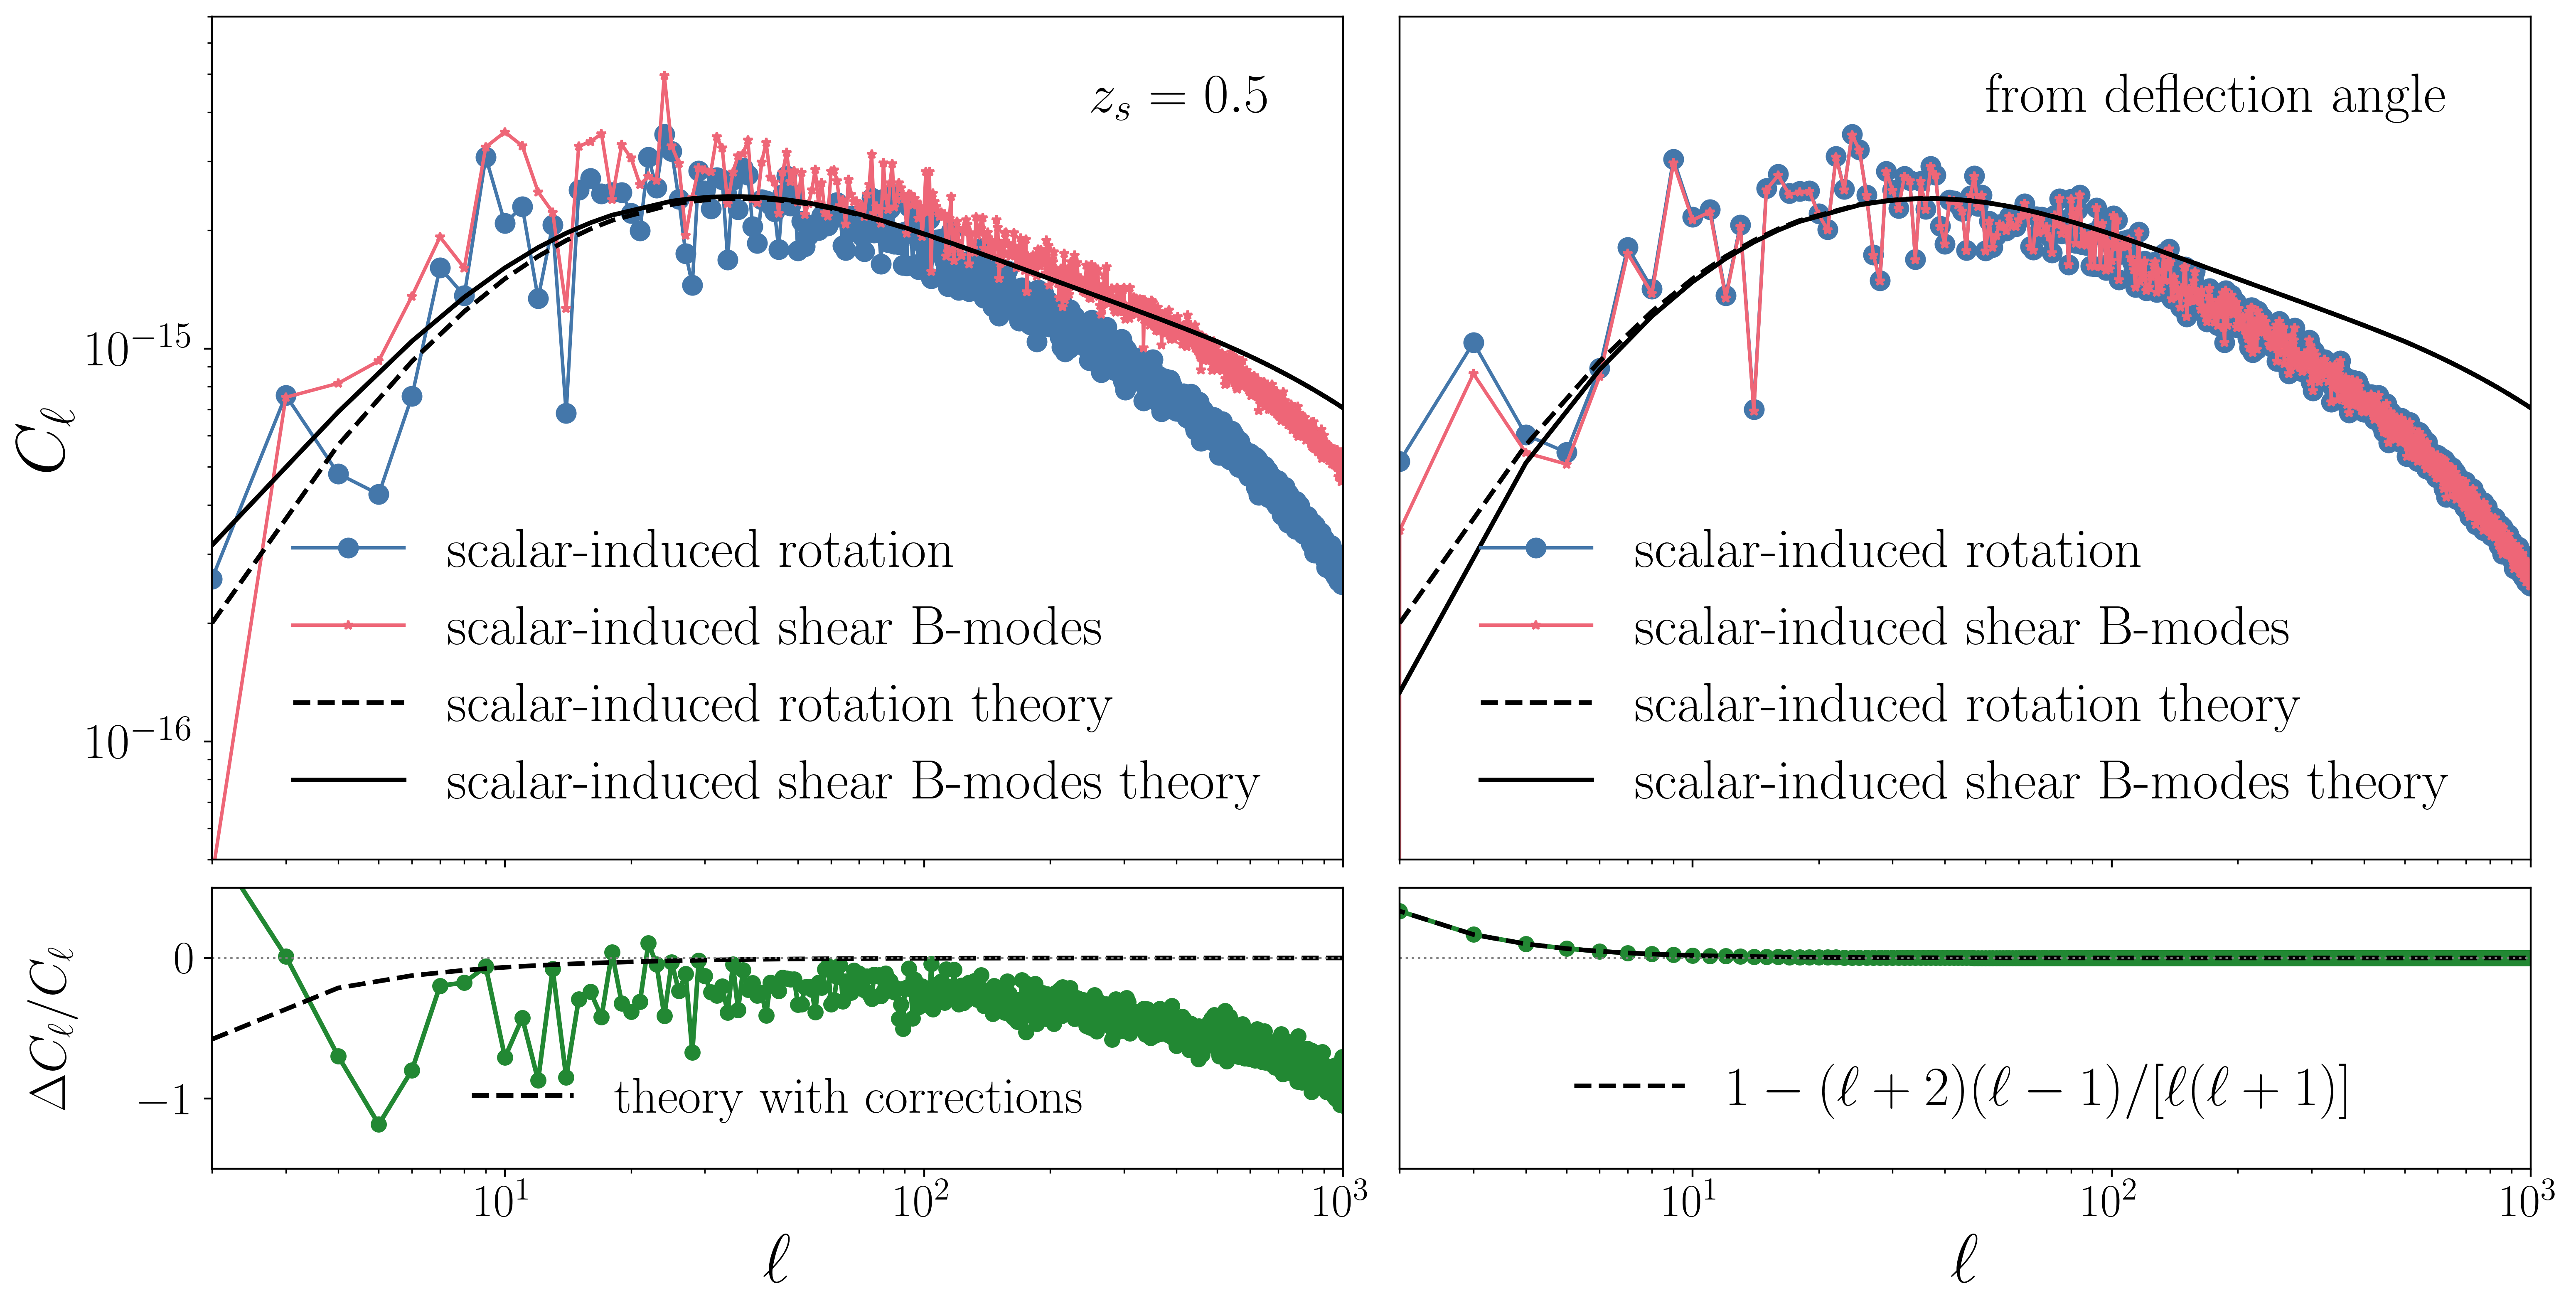

done


In [8]:
# =========================================================
# Fig. 3
# =========================================================

fig = plt.figure(figsize=(18, 9))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0.05,
    wspace=0.05
)
z_plot = 0.5
# ---- Top left
ax11 = fig.add_subplot(gs[0, 0])

ax11.plot(ell_noB, spectra[z_plot]['cl_omega_noB']    ,
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced rotation')

ax11.plot(ell_noB, spectra[z_plot]['cl_shear2_noB']   ,
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced shear B-modes')

ax11.plot(l, cl_omom,
          ls='--', lw=2, color='k',
          label=r'scalar-induced rotation theory')

ax11.plot(l, cl_omom + sum_corrections,
          ls='-', lw=2, color='k',
          label=r'scalar-induced shear B-modes theory')
ax11.set_xscale('log')
ax11.set_yscale('log')
ax11.set_ylim([5e-17, 7.0e-15])
ax11.set_xlim([2, 1000])

ax11.set_ylabel(r'$C_{\ell}$', fontsize=30)
ax11.legend(loc="lower center", fontsize=24, frameon=False)

ax11.tick_params(axis='y', labelsize=22)
ax11.tick_params(axis='x', labelbottom=False)

ax11.text(250, 4e-15, r'$z_s = 0.5$', fontsize=24)

# ---- Bottom left
ax21 = fig.add_subplot(gs[1, 0], sharex=ax11)

reldiff_1 = (spectra[z_plot]['cl_omega_noB'] - spectra[z_plot]['cl_shear2_noB']) / spectra[z_plot]['cl_omega_noB']    
reldiff_theory_1 = 1.0 - shear_factor(ell_noB)
reldiff_theory_true = 1.0 - (cl_omom + sum_corrections)/cl_omom

ax21.plot(ell_noB, reldiff_1,
          marker='o', color=list(cset)[2], lw=2)

ax21.plot(l, reldiff_theory_true,
          ls='--', color='k', lw=2,
          label=r'theory with corrections')

ax21.axhline(0.0, color='gray', ls=':', lw=1)

ax21.set_xscale('log')
ax21.set_xlim([2, 1000])
ax21.set_ylim([-1.5, 0.5])

ax21.set_ylabel(r'$\Delta C_{\ell} / C_{\ell}$', fontsize=22)
ax21.set_xlabel(r'$\ell$', fontsize=30)

ax21.tick_params(axis='both', labelsize=20)
ax21.legend(loc="lower center", fontsize=22, frameon=False)

# ---- Top right
ax12 = fig.add_subplot(gs[0, 1])

ax12.plot(ell_noB_def, spectra[z_plot]['cl_omega_noB_def'],
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced rotation')

ax12.plot(ell_noB_def, spectra[z_plot]['cl_shear2_noB_def'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced shear B-modes')

ax12.plot(l, cl_omom,
          ls='--', lw=2, color='k',
          label=r'scalar-induced rotation theory')

ax12.plot(l, cl_omom*shear_factor(l),
          ls='-', lw=2, color='k',
          label=r'scalar-induced shear B-modes theory')

ax12.text(50, 4e-15, r'from deflection angle', fontsize=24)

ax12.set_xscale('log')
ax12.set_yscale('log')
ax12.set_ylim([5e-17, 7.0e-15])
ax12.set_xlim([2, 1000])

#ax12.tick_params(axis='y', labelsize=22)
ax12.tick_params(axis='y', which='both', left=False, labelleft=False)
ax12.tick_params(axis='x', labelbottom=False)

ax12.legend(loc="lower center", fontsize=24, frameon=False)

# ---- Bottom right
ax22 = fig.add_subplot(gs[1, 1], sharex=ax12)

reldiff_2 = (spectra[z_plot]['cl_omega_noB_def'] - spectra[z_plot]['cl_shear2_noB_def']) / spectra[z_plot]['cl_omega_noB_def']
reldiff_theory_2 = 1.0 - shear_factor(ell_noB_def)

ax22.plot(ell_noB_def, reldiff_2,
          marker='o', color=list(cset)[2], lw=2)

ax22.plot(ell_noB_def, reldiff_theory_2,
          ls='--', color='k', lw=2, label=r'$1 - (\ell+2)(\ell-1)/[\ell(\ell+1)]$')

ax22.legend(loc="lower center", fontsize=24, frameon=False)

ax22.axhline(0.0, color='gray', ls=':', lw=1)
ax22.tick_params(axis='y', which='both', left=False, labelleft=False)

ax22.set_xscale('log')
ax22.set_xlim([2, 1000])
ax22.set_ylim([-1.5, 0.5])

ax22.set_xlabel(r'$\ell$', fontsize=30)
ax22.tick_params(axis='both', labelsize=20)

# =========================================================
# Final alignment
# =========================================================

fig.align_ylabels([ax11, ax21])
fig.align_ylabels([ax12, ax22])

plt.show()
#plt.savefig("Figures/scalar_rotation_shearB_fullJacobi_vs_deflection.pdf", bbox_inches="tight")
plt.close(fig)

print("done")

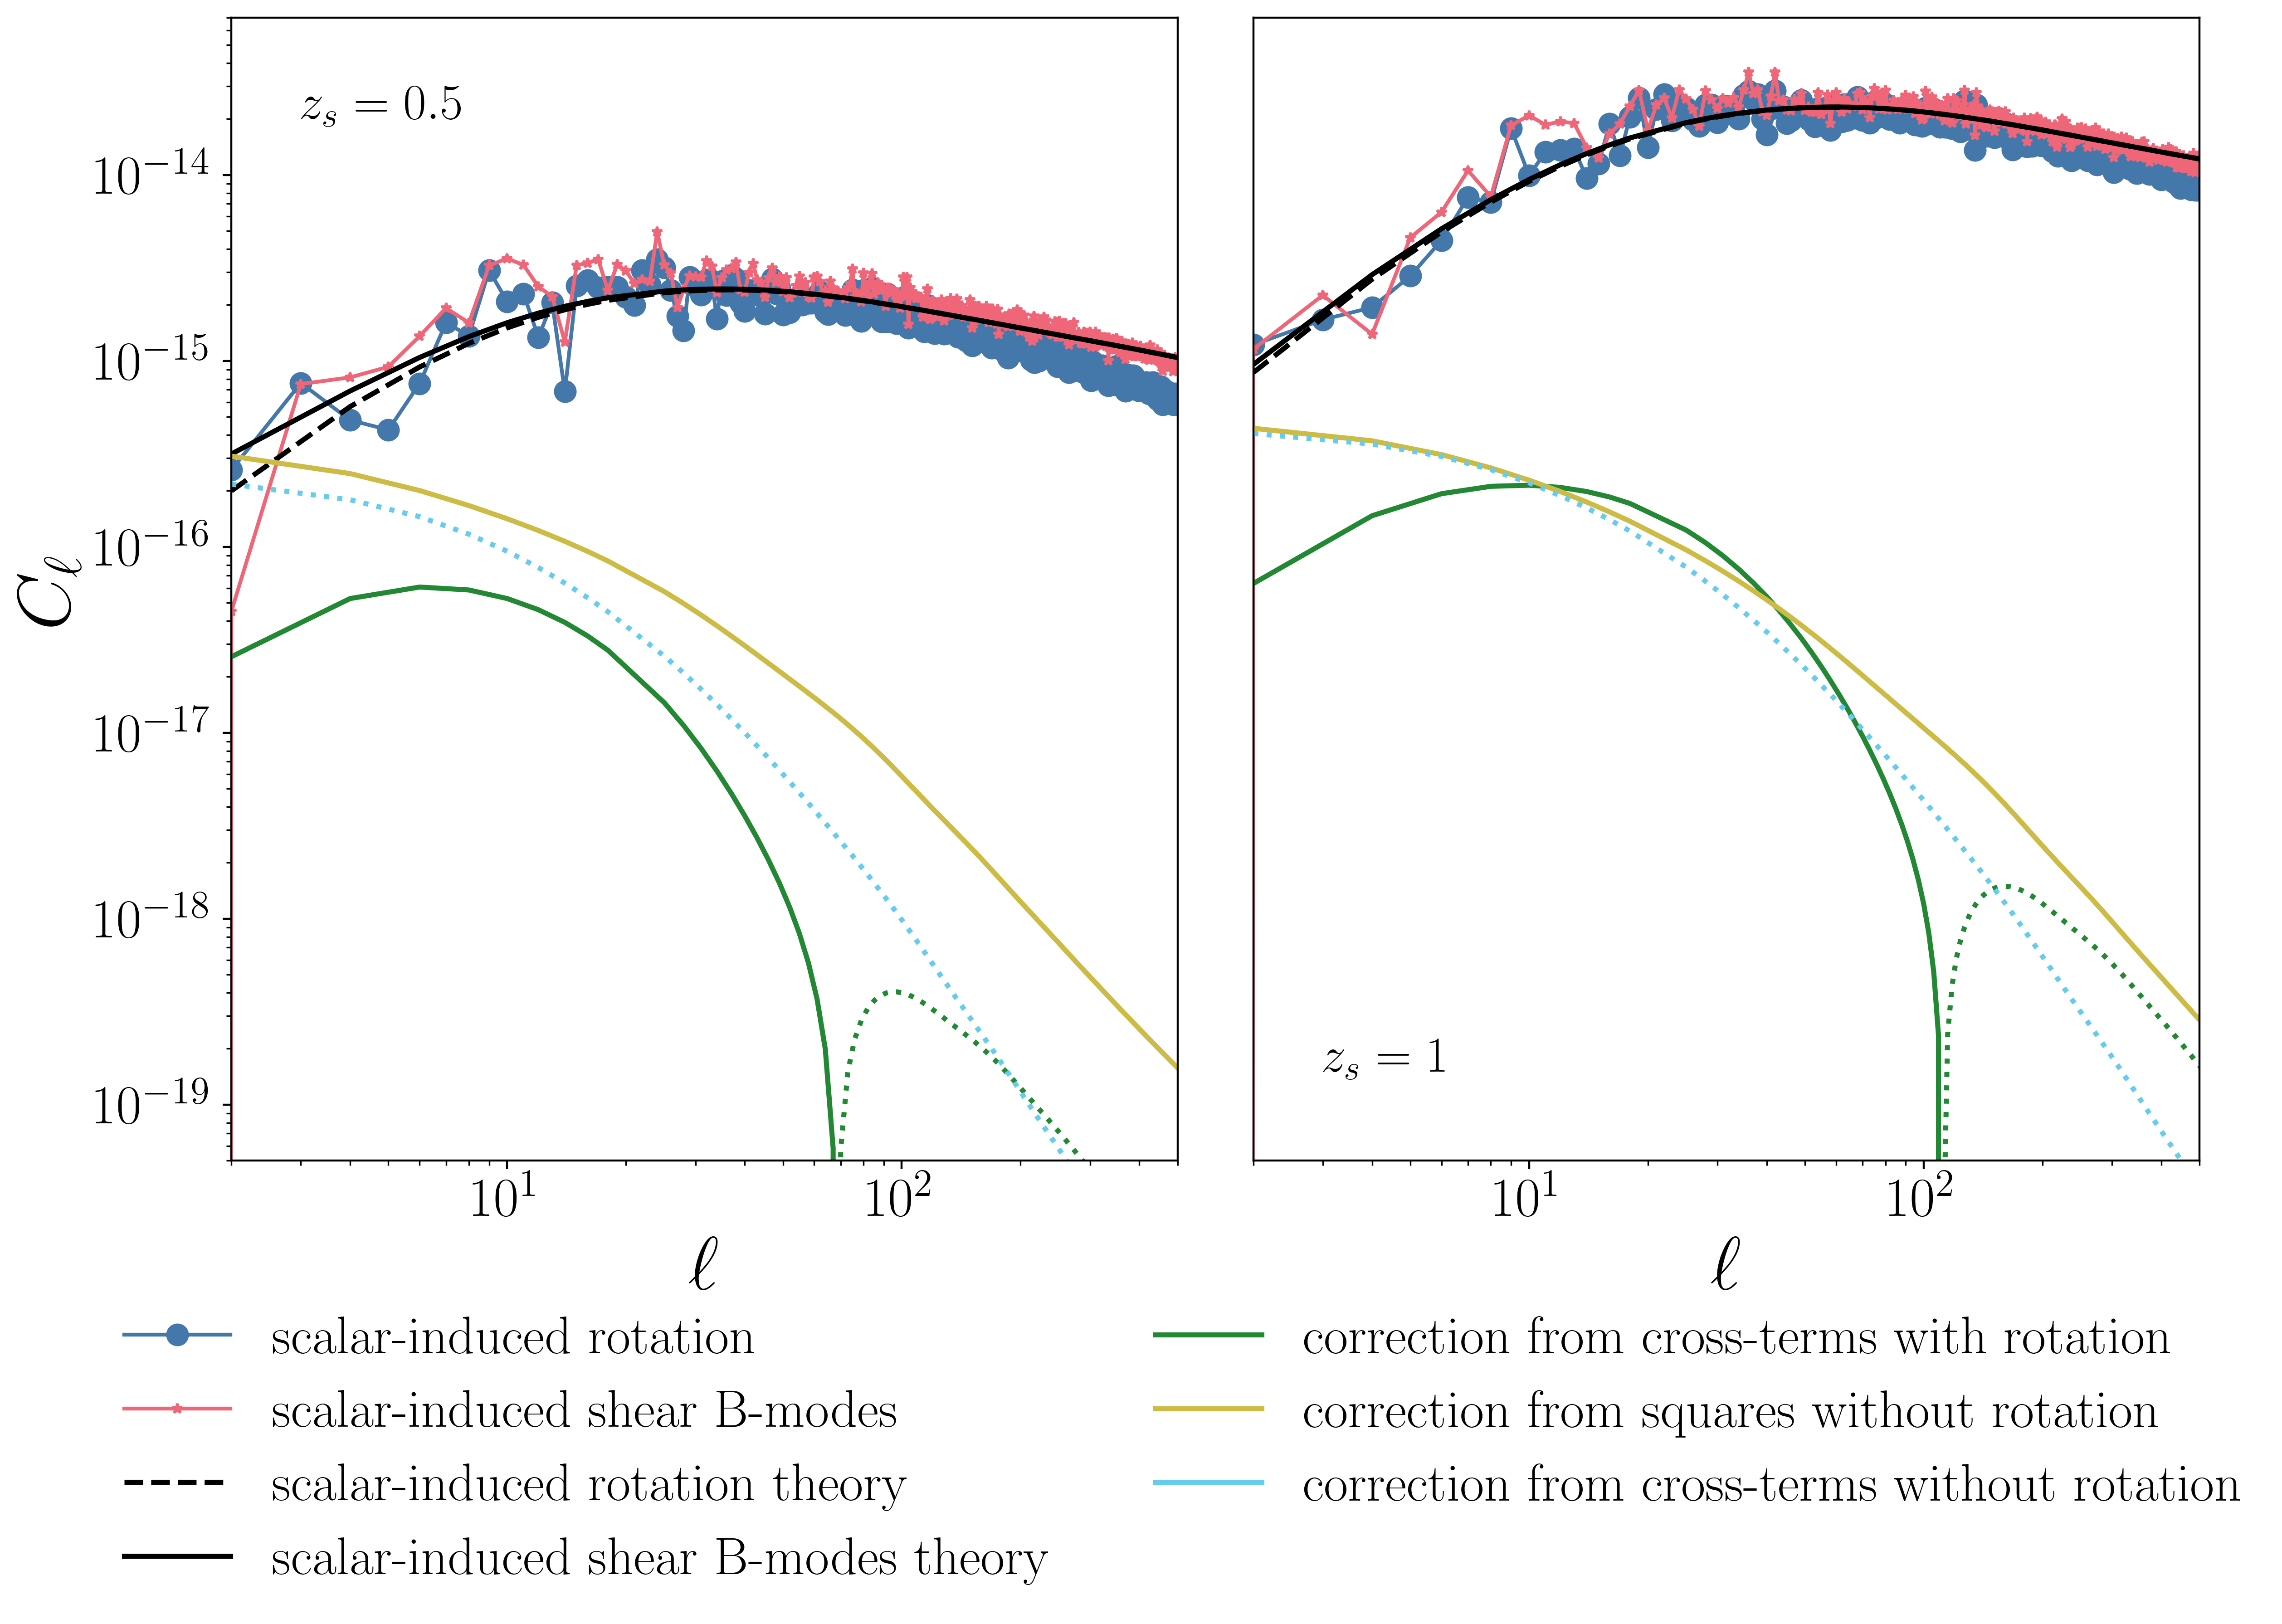

done


In [9]:
# =========================================================
# Fig. 4
# =========================================================
z_source = 0.5
z_source_z1 = 1.0

fig = plt.figure(figsize=(14,10))
gs = gridspec.GridSpec(
    1, 2,
    width_ratios=[1, 1],
    wspace=0.08  # adjust spacing between panels
)

# =========================================================
# LEFT PANEL 
# =========================================================

ax1 = fig.add_subplot(gs[0])

ax1.plot(ell_noB, spectra[z_source]['cl_omega_noB'] ,
         marker='o', mfc=list(cset)[0], color=list(cset)[0],
         ms=8, label=r'scalar rotation')

ax1.plot(ell_noB, spectra[z_source]['cl_shear2_noB'],
         marker='*', mfc=list(cset)[1], color=list(cset)[1],
         ms=4, label=r'scalar shear B-modes')

ax1.plot(l, cl_omom,
         ls='--', lw=2, color='k',
         label=r'scalar rotation theory')

ax1.plot(l, cl_omom + sum_corrections,
         ls='-', lw=2, color='k',
         label=r'scalar shear B-modes theory')

ax1.plot(l,  cl_shear_cross_rot,
         ls='-', lw=2, color=list(cset)[2],
         label=r'correction from cross-terms with rotation')

ax1.plot(l,  -cl_shear_cross_rot,
         ls=':', lw=2, color=list(cset)[2])

ax1.plot(l,  cl_shear_squares_norot,
         ls='-', lw=2, color=list(cset)[3],
         label=r'correction from squares without rotation')

ax1.plot(l,  -cl_shear_squares_norot,
         ls=':', lw=2, color=list(cset)[3])

ax1.plot(l,  cl_shear_cross_norot,
         ls='-', lw=2, color=list(cset)[4],
         label=r'correction from cross-terms without rotation')

ax1.plot(l,  -cl_shear_cross_norot,
         ls=':', lw=2, color=list(cset)[4])

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim([5e-20, 7e-14])
ax1.set_xlim([2, 500])

ax1.set_ylabel(r'$C_{\ell}$', fontsize=30)
#ax1.legend(loc="lower left", fontsize=18, frameon=False)

ax1.tick_params(axis='both', labelsize=22)

ax1.text(3, 2e-14, r'$z_s = 0.5$', fontsize=20)
ax1.set_xlabel(r'$\ell$', fontsize=30)
# =========================================================
# RIGHT PANEL 
# =========================================================
ax2 = fig.add_subplot(gs[1])

ax2.plot(ell_noB, spectra[z_source_z1]['cl_omega_noB'],
         marker='o', mfc=list(cset)[0], color=list(cset)[0],
         ms=8, label=r'scalar-induced rotation')

ax2.plot(ell_noB, spectra[z_source_z1]['cl_shear2_noB'],
         marker='*', mfc=list(cset)[1], color=list(cset)[1],
         ms=4, label=r'scalar-induced shear B-modes')

ax2.plot(l_z1, cl_omom_z1,
         ls='--', lw=2, color='k',
         label=r'scalar-induced rotation theory')

ax2.plot(l_z1, cl_omom_z1 + sum_corrections_z1,
         ls='-', lw=2, color='k',
         label=r'scalar-induced shear B-modes theory')

ax2.plot(l_z1, cl_shear_cross_rot_z1,
         ls='-', lw=2, color=list(cset)[2],
         label=r'correction from cross-terms with rotation')

ax2.plot(l_z1,  -cl_shear_cross_rot_z1,
         ls=':', lw=2, color=list(cset)[2])

ax2.plot(l_z1, cl_shear_squares_norot_z1,
         ls='-', lw=2, color=list(cset)[3],
         label=r'correction from squares without rotation')

ax2.plot(l_z1,  -(cl_shear_squares_norot_z1),
         ls=':', lw=2, color=list(cset)[3])

ax2.plot(l_z1,  cl_shear_cross_norot_z1,
         ls='-', lw=2, color=list(cset)[4],
         label=r'correction from cross-terms without rotation')

ax2.plot(l_z1,  -cl_shear_cross_norot_z1,
         ls=':', lw=2, color=list(cset)[4])

ax2.text(3, 1.5e-19, r'$z_s = 1$', fontsize=20)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim([5e-20, 7.0e-14])
ax2.set_xlim([2, 500])

# remove y-axis ticks and labels for the right panel
ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
ax2.tick_params(axis='both', labelsize=22)

ax2.set_xlabel(r'$\ell$', fontsize=30)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,                
    fontsize=21,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

plt.subplots_adjust(bottom=0.25)

# =========================================================
plt.show()
#plt.savefig("Figures/scalar_rotation_shearB_corr_contributions.pdf", bbox_inches="tight")
plt.close(fig)

print("done")


# Frame dragging (vector-induced) power spectra

In [10]:
"""
Fourier space dimensionless power spectrum of the vector potential B.
We use the CLASS cosmology code to compute the transfer functions.
"""
from scipy.interpolate import RegularGridInterpolator
from camb import model, initialpower

from classy import Class
from scipy.interpolate import interp1d
from scipy.integrate import quad_vec
#####################################################
# Cosmological parameters and other CLASS parameters
#####################################################
A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

non_linear = False

params = {# LambdaCDM + 2 massive neutrinos (cosmology used in simulation)
                   'h':0.67,
                   'Omega_b':0.049,
                   'Omega_cdm': 0.268580851704,
                   'k_pivot' : 0.05,
                   'A_s':2.215e-9,
                   'n_s':0.9619,
                   'T_cmb' : 2.7255,
                   'N_ncdm' : 2,
                   'N_ur' : 1.01533,
                   'T_ncdm' : '0.7164863646133482, 0.7164863646133482',
                   'deg_ncdm' : '1, 1',
                   'm_ncdm' : '0.00868907, 0.05'
                    }

# Run CLASS
cosmo_class = Class()
cosmo_class.set(params)
cosmo_class.set({'output':'mPk, dTk, vTk','lensing':'no',
        'z_pk' : '0.0, 0.1, 1.0, 2.0, 3.0', 
        'P_k_max_h/Mpc': 300.0,
        'gauge': 'Newtonian',
        'nbody_gauge_transfer_functions' : 'yes'
      })

if non_linear:
    cosmo_class.set({'non_linear' : 'HMCODE'})
    
cosmo_class.compute()

# -----------------------------------
# Precompute transfer functions
# -----------------------------------
def precompute_transfers(z, k_min=1e-5, k_max=1e2, nk=2000):
    k_sample = np.logspace(np.log10(k_min), np.log10(k_max), nk)

    # get CLASS outputs
    transfer = cosmo_class.get_transfer(z)
    k_vals = transfer['k (h/Mpc)']

    # build fast interpolators with np.interp
    def interp_table(name, divide_h=False):
        f = interp1d(k_vals, transfer[name], kind='cubic', fill_value='extrapolate')
        if non_linear:
            if (name == 'd_cdm'):
                arr = []
                for kx in k_sample:
                    arr.append(f(kx)*np.sqrt(cosmo_class.pk(kx*h,z)/cosmo_class.pk_lin(kx*h,z)))
                arr = np.array(arr)
            else:
                arr = f(k_sample)
        else:
            arr = f(k_sample)
        if divide_h:
            arr /= h
        return arr

    transfer_fast = {
        "k": k_sample,
        "theta_cdm": interp_table('t_cdm', divide_h=True),
        "delta_cdm": interp_table('d_cdm'),
        "theta_b": interp_table('t_b', divide_h=True),
        "delta_b": interp_table('d_b'),
        "theta_n1": interp_table('t_ncdm[1]', divide_h=True),
        "delta_n1": interp_table('d_ncdm[1]'),
    }
    return transfer_fast

# -----------------------------------
# Power spectrum helpers
# -----------------------------------
def primordial_power(k, A_s, n_s, h=0.67, k_pivot=0.05):
    return A_s * (k/(k_pivot*h))**(n_s - 1)

def DeltaR(k):
    return primordial_power(k, A_s=params['A_s'], n_s=params['n_s'], h=h)

def Hconf_z(z):
    return cosmo_class.Hubble(z) / (1.0+z) / h

# -----------------------------------
# Kernels (vectorized)
# -----------------------------------
def kernel_prefactor(w, u):
    return 0.25 * (1 + w**2 - u**2)**2 - w**2

def integrand_u(u, w, k, z, T):
    eps = 1e-40
    Kw, Ku = k*w, k*u

    t_cdm_w, t_cdm_u = np.interp([Kw, Ku], T['k'], T['theta_cdm'])
    d_cdm_w, d_cdm_u = np.interp([Kw, Ku], T['k'], T['delta_cdm'])

    t_b_w, t_b_u = np.interp([Kw, Ku], T['k'], T['theta_b'])
    d_b_w, d_b_u = np.interp([Kw, Ku], T['k'], T['delta_b'])

    t_n1_w, t_n1_u = np.interp([Kw, Ku], T['k'], T['theta_n1'])
    d_n1_w, d_n1_u = np.interp([Kw, Ku], T['k'], T['delta_n1'])

    Oc, Ob, On = cosmo_class.Om_cdm(z), cosmo_class.Om_b(z), cosmo_class.Om_ncdm(z)

    # We neglect neutrinos for simplicity
    term1 = (Oc * (t_cdm_w/(w**2+eps))*d_cdm_u +
             Ob * (t_b_w/(w**2+eps))*d_b_u)# + On * (t_n1_w/(w**2+eps))*d_n1_u)

    # We neglect neutrinos for simplicity
    bracket = (Oc*((t_cdm_u/(u**2+eps))*d_cdm_w - (t_cdm_w/(w**2+eps))*d_cdm_u) +
               Ob*((t_b_u/(u**2+eps))*d_b_w - (t_b_w/(w**2+eps))*d_b_u)) #+ On*((t_n1_u/(u**2+eps))*d_n1_w - (t_n1_w/(w**2+eps))*d_n1_u))

    val = term1 * bracket * DeltaR(Kw) * DeltaR(Ku) * kernel_prefactor(w, u)
    return val / (w**2 * u**2 + eps)

def integrand_w_log(logw, k, z, T):
    w = np.exp(logw)
    umin, umax = abs(w - 1.0), w + 1.0
    res_u, _ = quad_vec(integrand_u, umin, umax, args=(w,k,z,T), epsabs=1e-6, epsrel=1e-4)
    return res_u * w

# -----------------------------------
# Main \Delta_B(k,z) function
# -----------------------------------
def DeltaB(k, Hmath, z, T, w_max=100.0):
    prefactor = 18.0 * Hmath**4 / (k**6 + 1e-40)
    logw_min, logw_max = np.log(1e-4), np.log(w_max)
    result, _ = quad_vec(integrand_w_log, logw_min, logw_max, args=(k,z,T), epsabs=1e-6, epsrel=1e-4)
    return prefactor * result

# -----------------------------
# --- assume functions DeltaB, Hconf_z, precompute_transfers already defined above ---
# -----------------------------
# Spectrum computation
# -----------------------------
def compute_DeltaB_spectrum(k_values, z):
    """
    Compute Δ_B(k, z) for an array of k-values at fixed z.
    """
    DeltaB_values = np.zeros_like(k_values)
    Hmath = Hconf_z(z)
    T = precompute_transfers(z)

    for i, k in enumerate(k_values):
        DeltaB_values[i] = DeltaB(k, Hmath, z, T)
    return DeltaB_values


# Additional routine, not used here, but could be useful later
def compute_DeltaB_vs_z(k, z_values, w_max=100.0):
    """
    Compute DeltaB(k, z) for a fixed k and an array of redshifts z_values.
    
    Parameters
    ----------
    k : float
        Wavenumber [h/Mpc].
    z_values : array_like
        Redshift values at which to compute DeltaB.
    w_max : float, optional
        Upper cutoff in w integration. Default: 100.
    
    Returns
    -------
    results : np.ndarray
        Array of DeltaB(k, z) values corresponding to z_values.
    """
    results = []
    for z in z_values:
        # Precompute transfer functions at this z
        T = precompute_transfers(z)
        # Hubble at this z
        Hmath = Hconf_z(z)
        # Compute DeltaB
        val = DeltaB(k, Hmath, z, T, w_max=w_max)
        results.append(val)
    return np.array(results)

# Additional routine, not used here, but useful to implement the true vector-induced angular power spectra
def compute_DeltaB_array(k_values, z_values, w_max=100.0):
    """
    Compute DeltaB(k,z) for arrays of (k,z) pairs.
    Each k[i] corresponds to z[i].
    
    Parameters
    ----------
    k_values : array_like
        Array of wavenumbers [h/Mpc].
    z_values : array_like
        Array of redshifts (same length as k_values).
    w_max : float, optional
        Upper cutoff in w integration. Default: 100.
    
    Returns
    -------
    DeltaB_arr : np.ndarray
        Array of DeltaB(k[i], z[i]) values.
    """
    if len(k_values) != len(z_values):
        raise ValueError("k_values and z_values must have the same length.")
    
    DeltaB_arr = np.empty_like(k_values, dtype=np.float64)

    for i, (k, z) in enumerate(zip(k_values, z_values)):
        # Precompute transfer functions at this redshift
        T = precompute_transfers(0.25)
        # Hubble parameter
        Hmath = Hconf_z(0.25)
        # Compute DeltaB
        DeltaB_arr[i] = DeltaB(k, Hmath, 0.25, T, w_max=w_max)
    
    return DeltaB_arr

#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

pars.set_cosmology(H0=100.0*h, ombh2=Omega_b*h*h, omch2=Omega_cdm*h*h, TCMB = T_cmb, omk=0, tau=0.06)
camb.set_params(num_nu_massless = 1.01533, num_nu_massive = 2, nu_mass_eigenstates = 2, nu_mass_degeneracies = [1, 1], nu_mass_numbers = [1, 1], nu_mass_fractions = [0.1481, 0.8519], share_delta_neff = True) 
pars.InitPower.set_params(As=A_s, ns=n_s, r=0)
pars.set_for_lmax(3500, lens_potential_accuracy=0)

# redshift of the snapshot used for the ray-tracing
z_snap = 0.25 
results = camb.get_background(pars)

k_values = np.logspace(-4, 10.0,100, endpoint=True)

print('Start computation of Δ_B(k,z) spectrum:')
start = time.time()
DeltaB_theory = compute_DeltaB_spectrum(k_values, z_snap)
elapsed = time.time() - start
print(f"Computation finished in {elapsed:.2f} seconds")

Start computation of Δ_B(k,z) spectrum:
Computation finished in 128.33 seconds


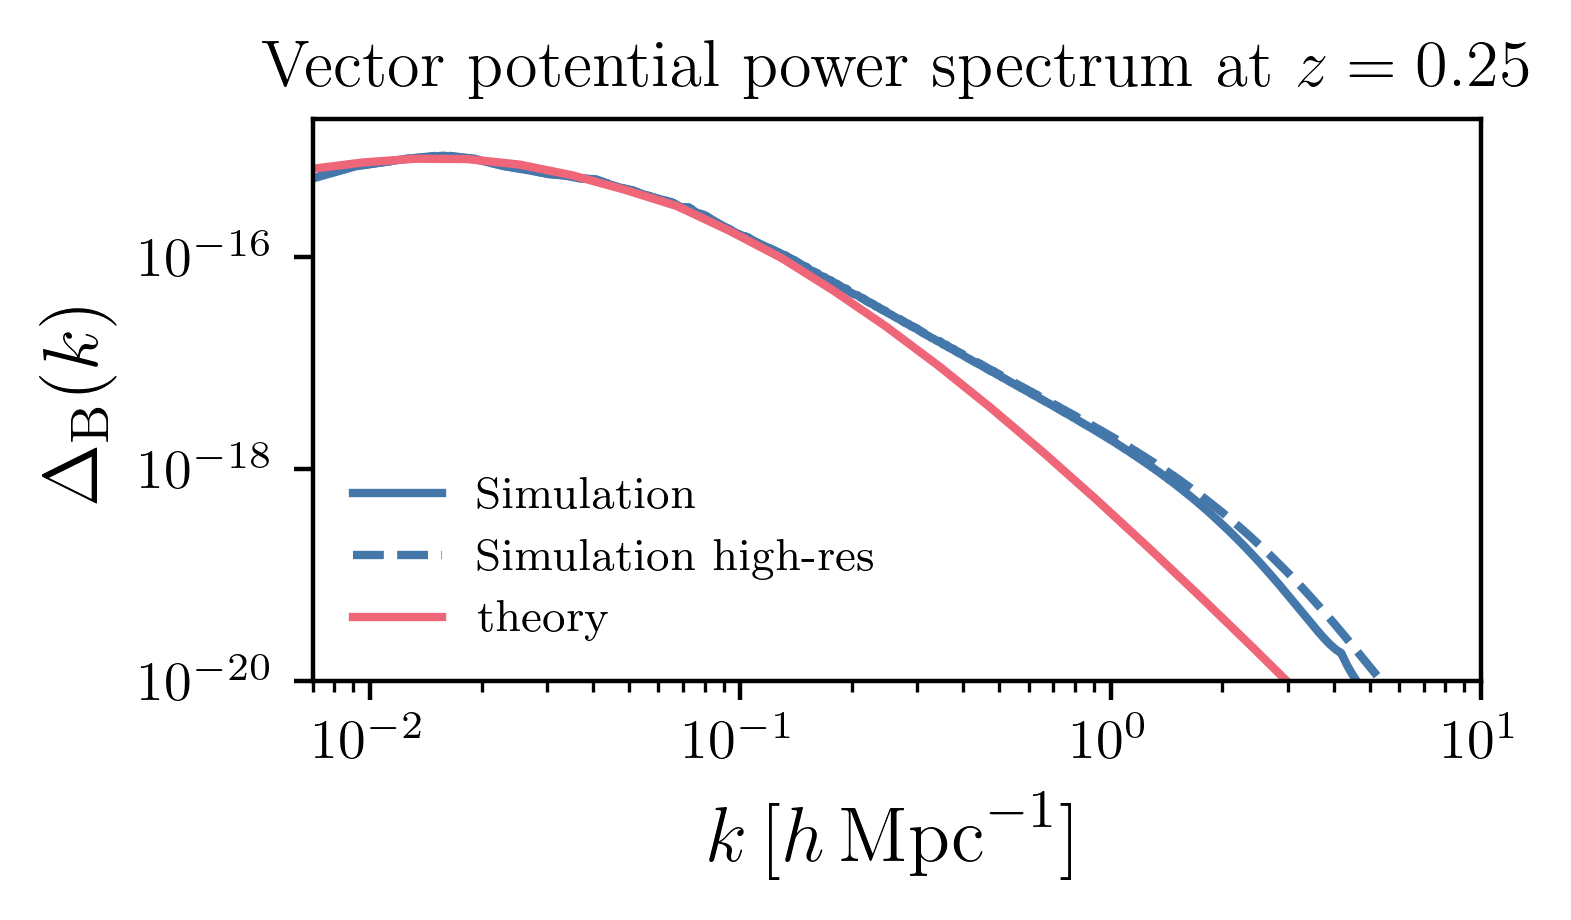

In [11]:
"""
We validate our theory computation of the vector potential power spectrum against simulation data.
This Figure does not appear on the paper, but was used to validate the theory code.
"""

# Load first two columns
path = 'sim-data/'
data = np.loadtxt(path + "lc_1440box_1920_pk007_B.dat", usecols=(0, 1))

# Store into variables
ktest = data[:, 0]
DeltaB_sim_z025 = data[:, 1]

# Load first two columns
path = 'sim-data/'
data = np.loadtxt(path + "lc_1440box_2880_pk007_B.dat", usecols=(0, 1))

# Store into variables
ktest_hr = data[:, 0]
DeltaB_sim_z025_hr = data[:, 1]

plt.subplot(1, 1, 1)

plt.loglog(ktest, DeltaB_sim_z025, color = list(cset)[0], label = 'Simulation')
plt.loglog(ktest_hr, DeltaB_sim_z025_hr, color = list(cset)[0],ls = '--', label = 'Simulation high-res')
plt.loglog(k_values, DeltaB_theory, color = list(cset)[1], label = 'theory')

plt.xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$', fontsize = 14)
plt.ylabel(r'$\Delta_\mathrm{B}(k)$', fontsize = 14)
plt.title(r'Vector potential power spectrum at $z=0.25$', fontsize = 12)
plt.xlim(7.0e-3, 10.0)    
plt.ylim(1.0e-20, 2.0e-15)
#plt.grid(True)
plt.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
"""
We model nonlinear corrections beyond second-order in perturbation theory 
by combining the theory prediction at large scales with the simulation results 
at small scales.
"""

from scipy.interpolate import CubicSpline
# Create spline
cs_lin = CubicSpline(k_values, DeltaB_theory)
cs_nonlin = CubicSpline(ktest_hr, DeltaB_sim_z025_hr)

def compute_DeltaB_array_nl(k_values, z_values, wmax = 10.0):
    """
    Nonlinear version: use simulation results at small scales (k > 0.1 h/Mpc)
    and theory results at large scales (k < 0.1 h/Mpc).
    """
    if len(k_values) != len(z_values):
        raise ValueError("k_values and z_values must have the same length.")
    DeltaB_arr = np.empty_like(k_values, dtype=np.float64)
    for i, (k, z) in enumerate(zip(k_values, z_values)):
        if (k < 0.1):
            DeltaB_arr[i] = cs_lin(k) 
        else:
            DeltaB_arr[i] = cs_nonlin(k)
    return DeltaB_arr 

def compute_DeltaB_array_l(k_values, z_values, wmax = 10.0):
    """
    Linear version: use theory results at all scales.
    """
    if len(k_values) != len(z_values):
        raise ValueError("k_values and z_values must have the same length.")
    DeltaB_arr = np.empty_like(k_values, dtype=np.float64)
    for i, (k, z) in enumerate(zip(k_values, z_values)):
        DeltaB_arr[i] = cs_lin(k) 
    return DeltaB_arr 

# ---------------------------------------------
# Vector-induced shear angular power spectrum
# ---------------------------------------------

def cl_shear_limber_vector(results, ls, nz, chi_source, chi_source2=None, non_linear=True):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win =  (1.0/(4.0*chis)) 
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    z_source = results.redshift_at_comoving_radial_distance(chi_source)
    for i, ll in enumerate(ls):
        k = (ll + 0.5) / (chis*h)
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= 10.0] = 0
        if (non_linear):
            DeltaB_z = compute_DeltaB_array_nl(k, zs)
        else:
            DeltaB_z = compute_DeltaB_array_l(k, zs)
        cl[i] = np.dot(dchis, w * DeltaB_z * win)
    cl *= np.pi**2/ls
    return cl

#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

pars.set_cosmology(H0=100.0*h, ombh2=Omega_b*h*h, omch2=Omega_cdm*h*h, TCMB = T_cmb, omk=0, tau=0.06)
camb.set_params(num_nu_massless = 1.01533, num_nu_massive = 2, nu_mass_eigenstates = 2, nu_mass_degeneracies = [1, 1], nu_mass_numbers = [1, 1], nu_mass_fractions = [0.1481, 0.8519], share_delta_neff = True) 
pars.InitPower.set_params(As=A_s, ns=n_s, r=0)
pars.set_for_lmax(3500, lens_potential_accuracy=0);

z_source = 1.0
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

lmax = 1000
acc = 3.0
nz = int(100 * acc)

#lsamp_vec = np.arange(2, 1000, 5).astype(np.float64)
lsamp_vec = np.hstack((np.arange(2, 10, 1), np.arange(11, 100, 4),
                    np.arange(101, lmax, 25))).astype(np.float64)

print('Theory computation of vector-induced shear B angular power spectra at z = 1 and z = 0.5:')
start = time.time()
cl_shear_vector_z1 = cl_shear_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=True)
cl_shear_vector_z1_lin = cl_shear_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=False)
elapsed = time.time() - start

print(f"Computation at z = 1 finished in {elapsed:.2f} seconds")

z_source = 0.5
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

lsamp_vec = np.hstack((np.arange(2, 10, 1), np.arange(11, 100, 4),
                    np.arange(101, lmax, 25))).astype(np.float64)

start = time.time()
cl_shear_vector_z05 = cl_shear_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=True)
cl_shear_vector_z05_lin = cl_shear_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=False)
elapsed = time.time() - start

print(f"Computation z = 0.5 finished in {elapsed:.2f} seconds")

Theory computation of vector-induced shear B angular power spectra at z = 1 and z = 0.5:
Computation at z = 1 finished in 0.21 seconds
Computation z = 0.5 finished in 0.20 seconds


In [13]:
# ---------------------------------------------
# Vector-induced convergence angular power spectrum
# (follow the same structure as the shear one)
# ---------------------------------------------

def cl_kappa_limber_vector(results, ls, nz, chi_source, chi_source2=None, non_linear=True):
    chi_source = np.float64(chi_source)
    if chi_source2 is None:
        chi_source2 = chi_source
    else:
        chi_source2 = np.float64(chi_source2)
        if chi_source2 < chi_source:
            chi_source, chi_source2 = chi_source2, chi_source
    chis = np.linspace(0, chi_source, nz, dtype=np.float64)
    zs = results.redshift_at_comoving_radial_distance(chis)
    dchis = (chis[2:] - chis[:-2]) / 2
    chis = chis[1:-1]
    zs = zs[1:-1]
    win =  (1 / chis - 1 / chi_source) * (1 / chis - 1 / chi_source2) * chis
    cl = np.zeros(ls.shape)
    w = np.ones(chis.shape)
    z_source = results.redshift_at_comoving_radial_distance(chi_source)
    for i, l in enumerate(ls):
        k = (l + 0.5) / (chis*h)
        w[:] = 1
        w[k < 1e-4] = 0
        w[k >= 10.0] = 0
        if (non_linear):
            DeltaB_z = compute_DeltaB_array_nl(k, zs)
        else:
            DeltaB_z = compute_DeltaB_array_l(k, zs)
        cl[i] = np.dot(dchis, w * DeltaB_z * win)
    cl *= 8*np.pi**2/((2.0*ls + 1)**5) * (ls * (ls + 1)) ** 3
    return cl


z_source = 1.0
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

lmax = 1000
acc = 3.0
nz = int(100 * acc)

lsamp_vec = np.hstack((np.arange(2, 10, 1), np.arange(11, 100, 4),
                    np.arange(101, lmax, 25))).astype(np.float64)

print('Theory computation of vector-induced convergence angular power spectra at z = 1 and z = 0.5:')
start = time.time()
cl_kappa_vector_z1 = cl_kappa_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=True)
cl_kappa_vector_z1_lin = cl_kappa_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=False)
elapsed = time.time() - start

print(f"Computation finished in {elapsed:.2f} seconds (z = 1)")

z_source = 0.5
results = camb.get_background(pars)
chi_source = results.comoving_radial_distance(z_source)

start = time.time()
cl_kappa_vector_z05 = cl_kappa_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=True)
cl_kappa_vector_z05_lin = cl_kappa_limber_vector(results, lsamp_vec, nz, chi_source, non_linear=False)
elapsed = time.time() - start

print(f"Computation finished in {elapsed:.2f} seconds (z = 0.5)")

Theory computation of vector-induced convergence angular power spectra at z = 1 and z = 0.5:
Computation finished in 0.20 seconds (z = 1)
Computation finished in 0.20 seconds (z = 0.5)


done


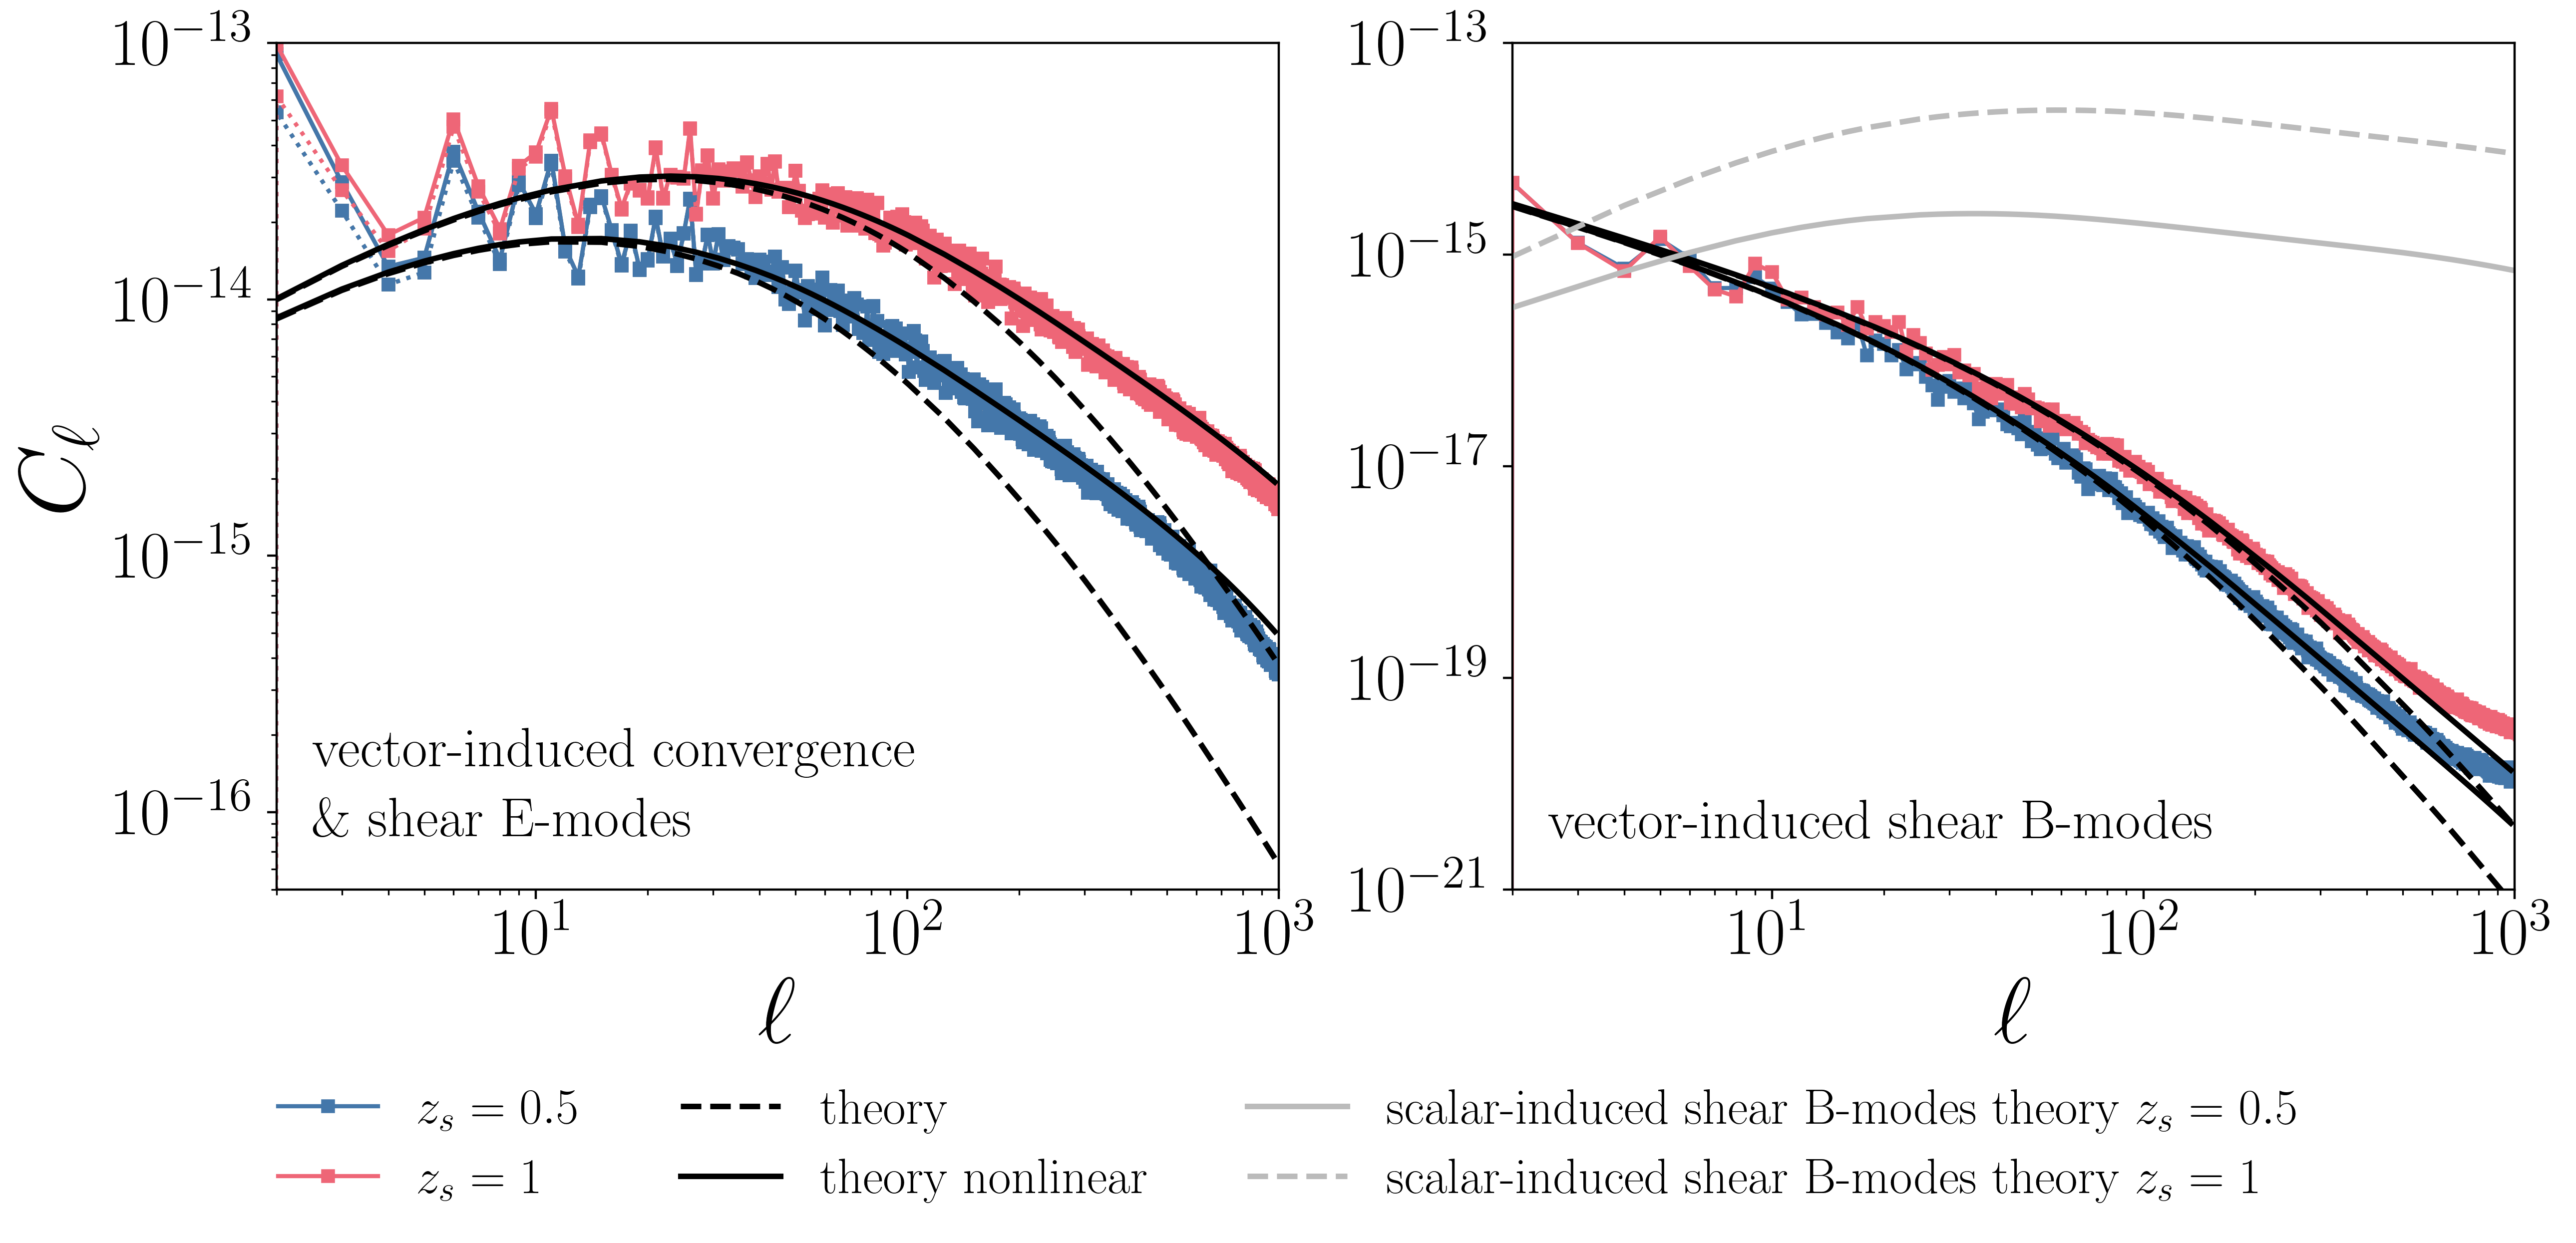

In [14]:
# =========================================================
# Fig. 5
# =========================================================

import matplotlib.pyplot as plt
import pylab

fig, (ax_left, ax_right) = plt.subplots(
    nrows=1, ncols=2, figsize=(13, 6), sharex=True
)

# ============================================================
# LEFT PANEL: Vector-induced convergence
# ============================================================
zm1 = 0.5
zm2 = 1.0
ax_left.plot(
    ell_B, spectra[zm1]['cl_kappa_B'],
    marker='s', mfc='grey', color='grey',
    lw=1.5, ls='-', ms=4, label=r'convergence'
)

ax_left.plot(
    ell_B, spectra[zm1]['cl_shear1_B'],
    marker='s', mfc='grey', color='grey',
    lw=1.5, ls=':', ms=4, label=r'shear E-modes')

ax_left.plot(
    ell_B, spectra[zm1]['cl_kappa_B'],
    marker='s', mfc=list(cset)[0], color=list(cset)[0],
    lw=1.5, ls='-', ms=4, label=r'$z = 0.5$'
)

ax_left.plot(
    ell_B, spectra[zm2]['cl_kappa_B'],
    marker='s', mfc=list(cset)[1], color=list(cset)[1],
    lw=1.5, ls='-', ms=4, label=r'$z = 1$'
)

ax_left.plot(
    ell_B, spectra[zm1]['cl_shear1_B'],
    marker='s', mfc=list(cset)[0], color=list(cset)[0],
    lw=1.5, ls=':', ms=4)

ax_left.plot(
    ell_B, spectra[zm2]['cl_shear1_B'],
    marker='s', mfc=list(cset)[1], color=list(cset)[1],
    lw=1.5, ls=':', ms=4)

ax_left.plot(
    lsamp_vec, cl_kappa_vector_z05_lin,
    ls='--', lw=2, color='k', label=r'theory'
)

ax_left.plot(
    lsamp_vec, cl_kappa_vector_z05,
    ls='-', lw=2, color='k', label=r'theory nonlinear'
)

ax_left.plot(lsamp_vec, cl_kappa_vector_z1_lin, ls='--', lw=2, color='k')
ax_left.plot(lsamp_vec, cl_kappa_vector_z1,     ls='-',  lw=2, color='k')

ax_left.text(2.5, 1.5e-16, r'vector-induced convergence', fontsize=20)
ax_left.text(2.5, 8e-17, r'\& shear E-modes', fontsize=20)

ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.set_xlim(2, 1000)
ax_left.set_ylim(5e-17, 1e-13)

ax_left.set_xlabel(r'$\ell$', fontsize=34)
ax_left.set_ylabel(r'$C_\ell$', fontsize=34)

ax_left.tick_params(axis='both', which='major', labelsize=24)

# ============================================================
# RIGHT PANEL: Vector-induced shear B-modes
# ============================================================

ax_right.plot(
    ell_B, spectra[zm1]['cl_shear2_B'],
    marker='s', mfc=list(cset)[0], color=list(cset)[0],
    lw=1.5, ls='-', ms=4, label=r'$z_s = 0.5$'
)

ax_right.plot(
    ell_B, spectra[zm2]['cl_shear2_B'],
    marker='s', mfc=list(cset)[1], color=list(cset)[1],
    lw=1.5, ls='-', ms=4, label=r'$z_s = 1$'
)


ax_right.plot(
    lsamp_vec, cl_shear_vector_z05_lin,
    ls='--', lw=2, color='k', label=r'theory'
)

ax_right.plot(
    lsamp_vec, cl_shear_vector_z05,
    ls='-', lw=2, color='k', label=r'theory nonlinear'
)

ax_right.plot(lsamp_vec, cl_shear_vector_z1_lin, ls='--', lw=2, color='k')
ax_right.plot(lsamp_vec, cl_shear_vector_z1,     ls='-',  lw=2, color='k')

ax_right.plot(
    l, cl_omom + sum_corrections,
    ls='-', lw=2, color=list(cset)[6],
    label=r'scalar-induced shear B-modes theory $z_s = 0.5$'
)

ax_right.plot(
    l_z1, cl_omom_z1 + sum_corrections_z1,
    ls='--', lw=2, color=list(cset)[6],
    label=r'scalar-induced shear B-modes theory $z_s = 1$'
)

ax_right.text(2.5, 3e-21, r'vector-induced shear B-modes', fontsize=20)

ax_right.set_xscale('log')
ax_right.set_yscale('log')
ax_right.set_xlim(2, 1000)
ax_right.set_ylim(1e-21, 1e-13)

ax_right.set_xlabel(r'$\ell$', fontsize=34)
ax_right.tick_params(axis='both', which='major', labelsize=24)

# ============================================================
# COMMON EXTERNAL LEGEND (from right panel)
# ============================================================

handles, labels = ax_right.get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=3,
    fontsize=18,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05)
)

# ============================================================
# Final layout and save
# ============================================================

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    'Figures/Vector_kappa_shearB.pdf',
    format="PDF",
    bbox_inches='tight',
    dpi=300
)

print('done')



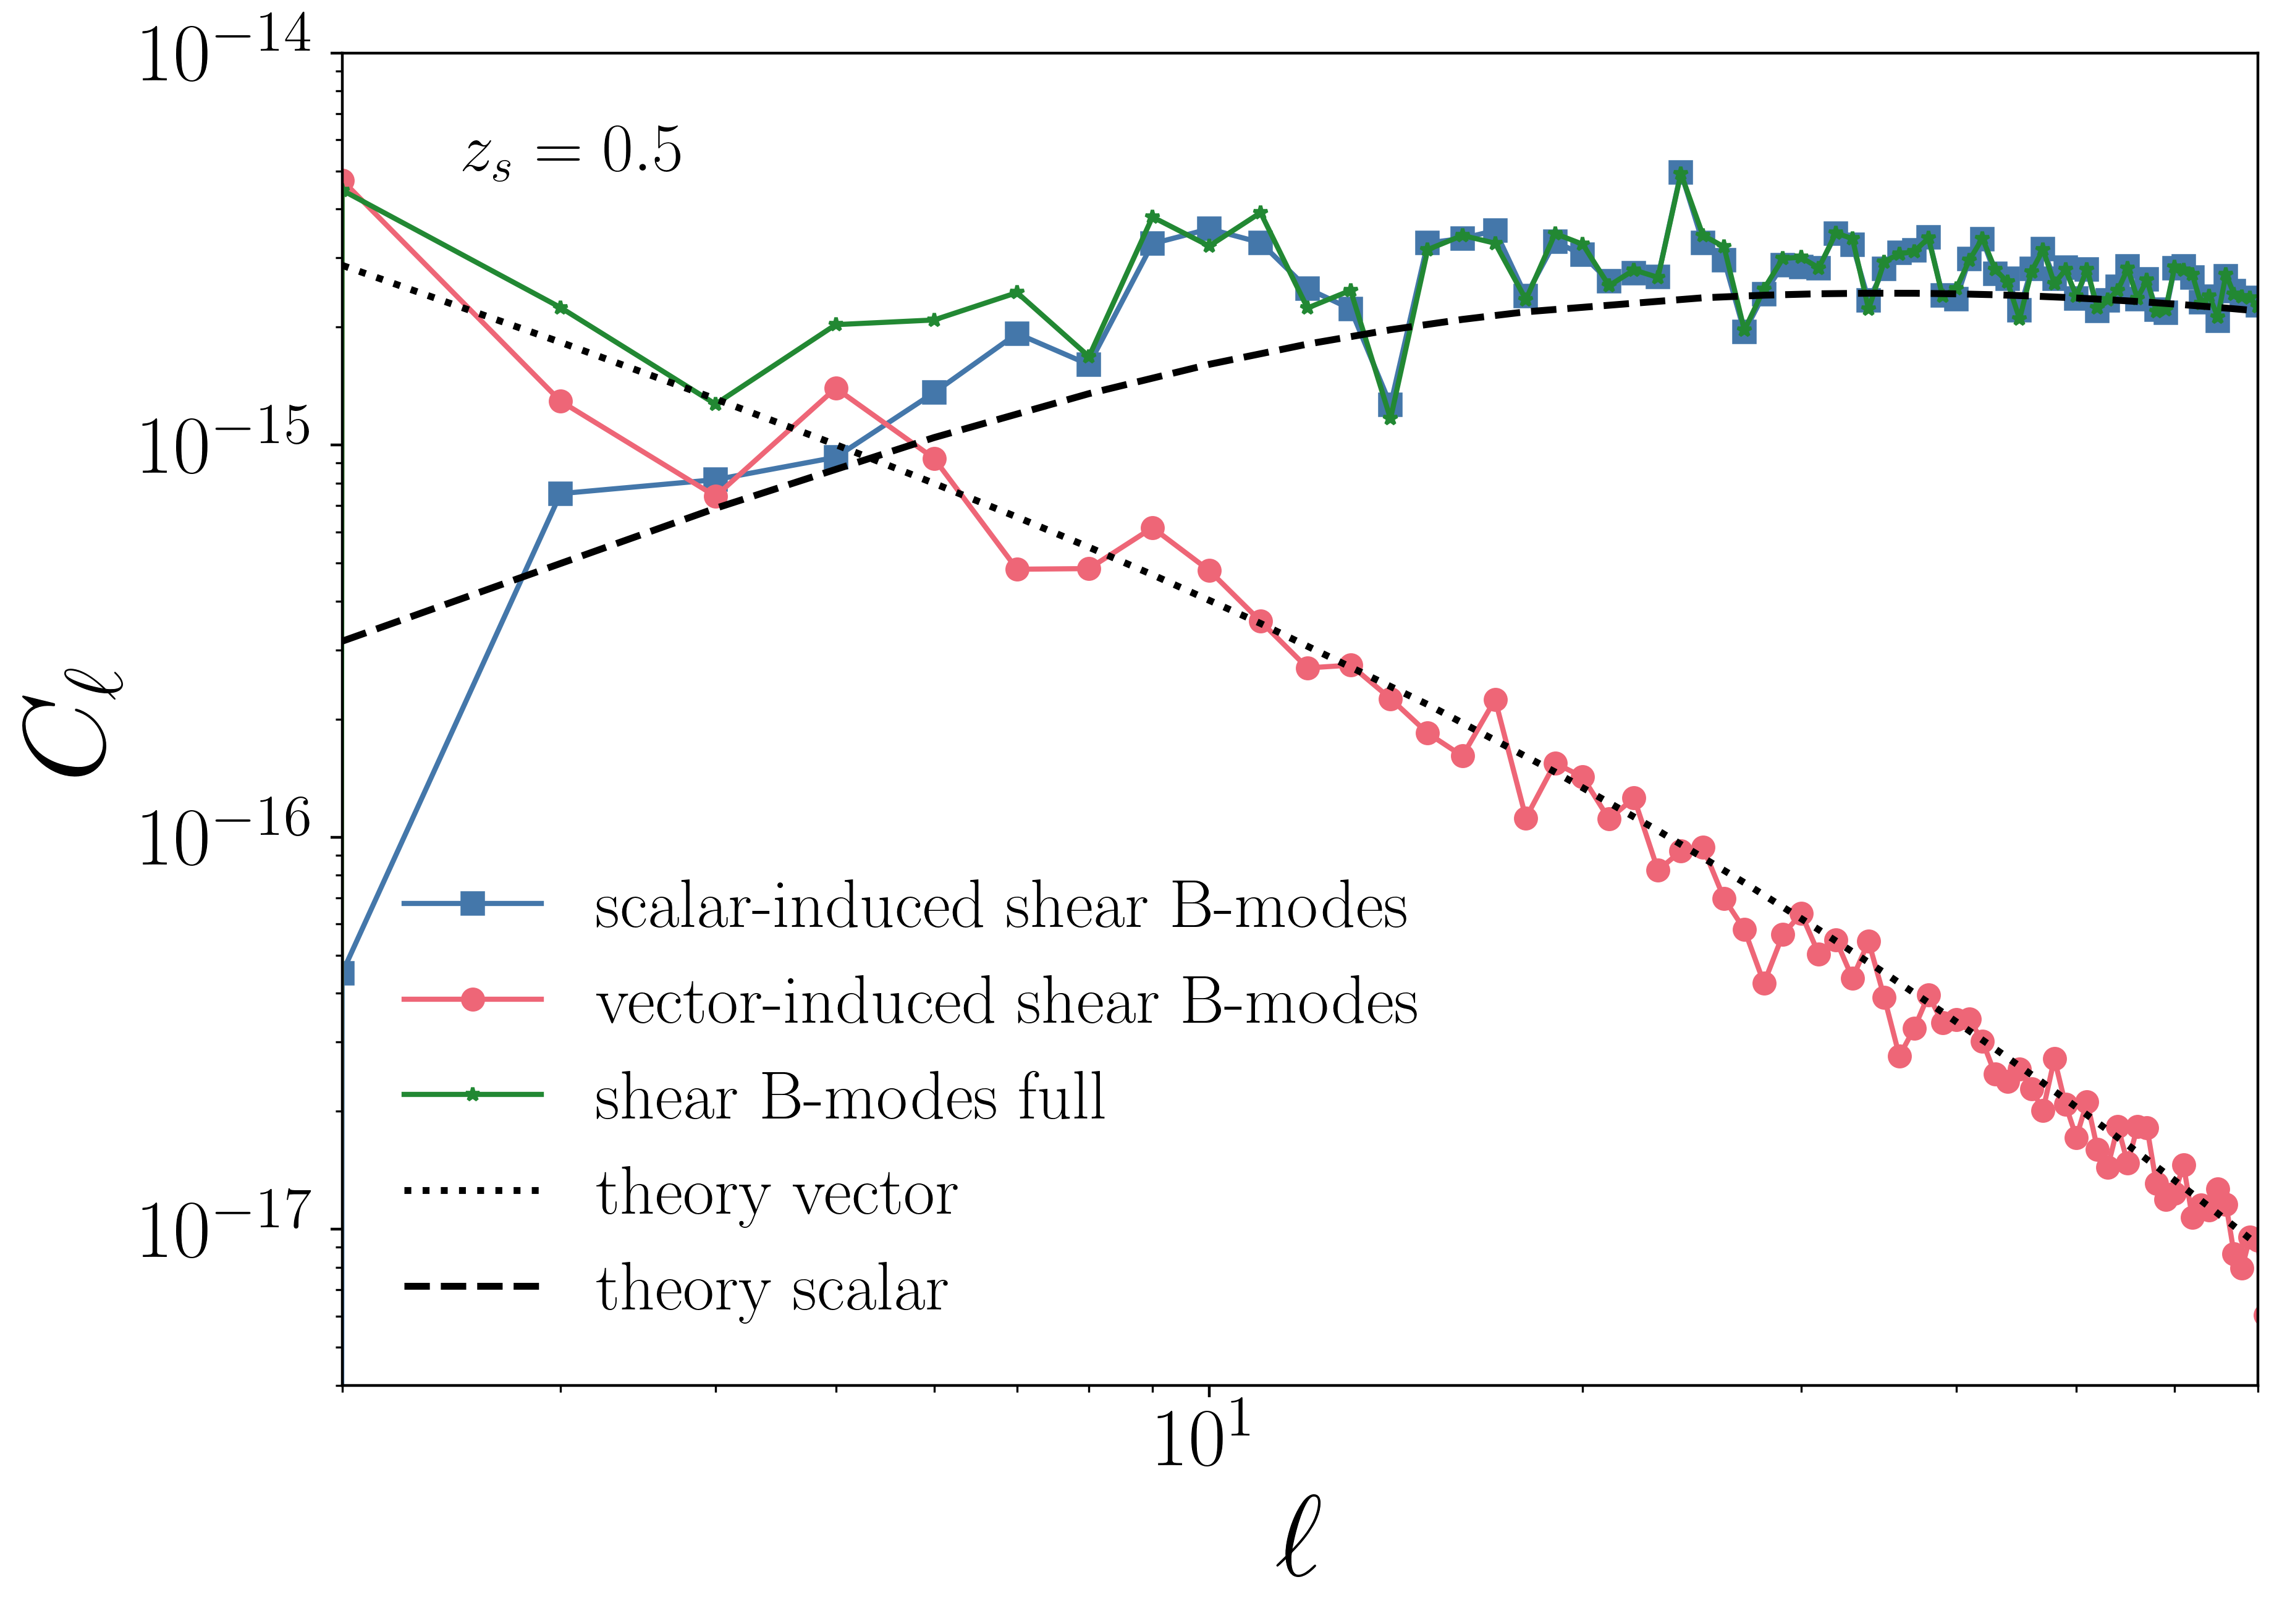

done


In [15]:
# =========================================================
# Fig. 6
# =========================================================

fig = plt.figure(figsize=(10,7))
ax1 = plt.subplot()

ax1.plot(ell_noB, spectra[0.5]['cl_shear2_noB'], marker='s', mfc=list(cset)[0], color = list(cset)[0], lw = 1.5, ls = '-', ms=6,label = r'scalar-induced shear B-modes')
ax1.plot(ell_B, spectra[0.5]['cl_shear2_B'] , marker='o', mfc=list(cset)[1], color = list(cset)[1], lw = 1.5, ls = '-', ms=6,label = r'vector-induced shear B-modes')
ax1.plot(ell, spectra[0.5]['cl_shear2'], marker='*', mfc=list(cset)[2], color = list(cset)[2], lw = 1.5, ls = '-', ms=4,label = r'shear B-modes full')

ax1.plot(lsamp_vec,  cl_shear_vector_z05, ls = ':', lw = '2', color='k', label = r'theory vector')
ax1.plot(l, cl_omom + sum_corrections, ls='--', lw=2, color='k', label=r'theory scalar')

ax1.text(2.5, 5e-15, r'$z_s = 0.5$', fontsize=20)

plt.legend(loc = "lower left", fontsize = 20, frameon=False, ncol = 1)

plt.ylabel('$C_{\ell}$', fontsize = 34)

pylab.ylim([4e-18, 1e-14])

plt.xscale('log')
plt.yscale('log')
plt.yticks(fontsize=24)

plt.yticks(fontsize=24)
plt.xticks(fontsize=24)

plt.xlabel('$\ell$', fontsize = 34) 
pylab.xlim([2, 70])

#plt.savefig('Figures/Vector_shearBmodes_z05.pdf', format = "PDF", bbox_inches='tight', edgecolor="k", dpi = 300)
plt.show()
plt.close(fig)
print('done')

# Ellipticity

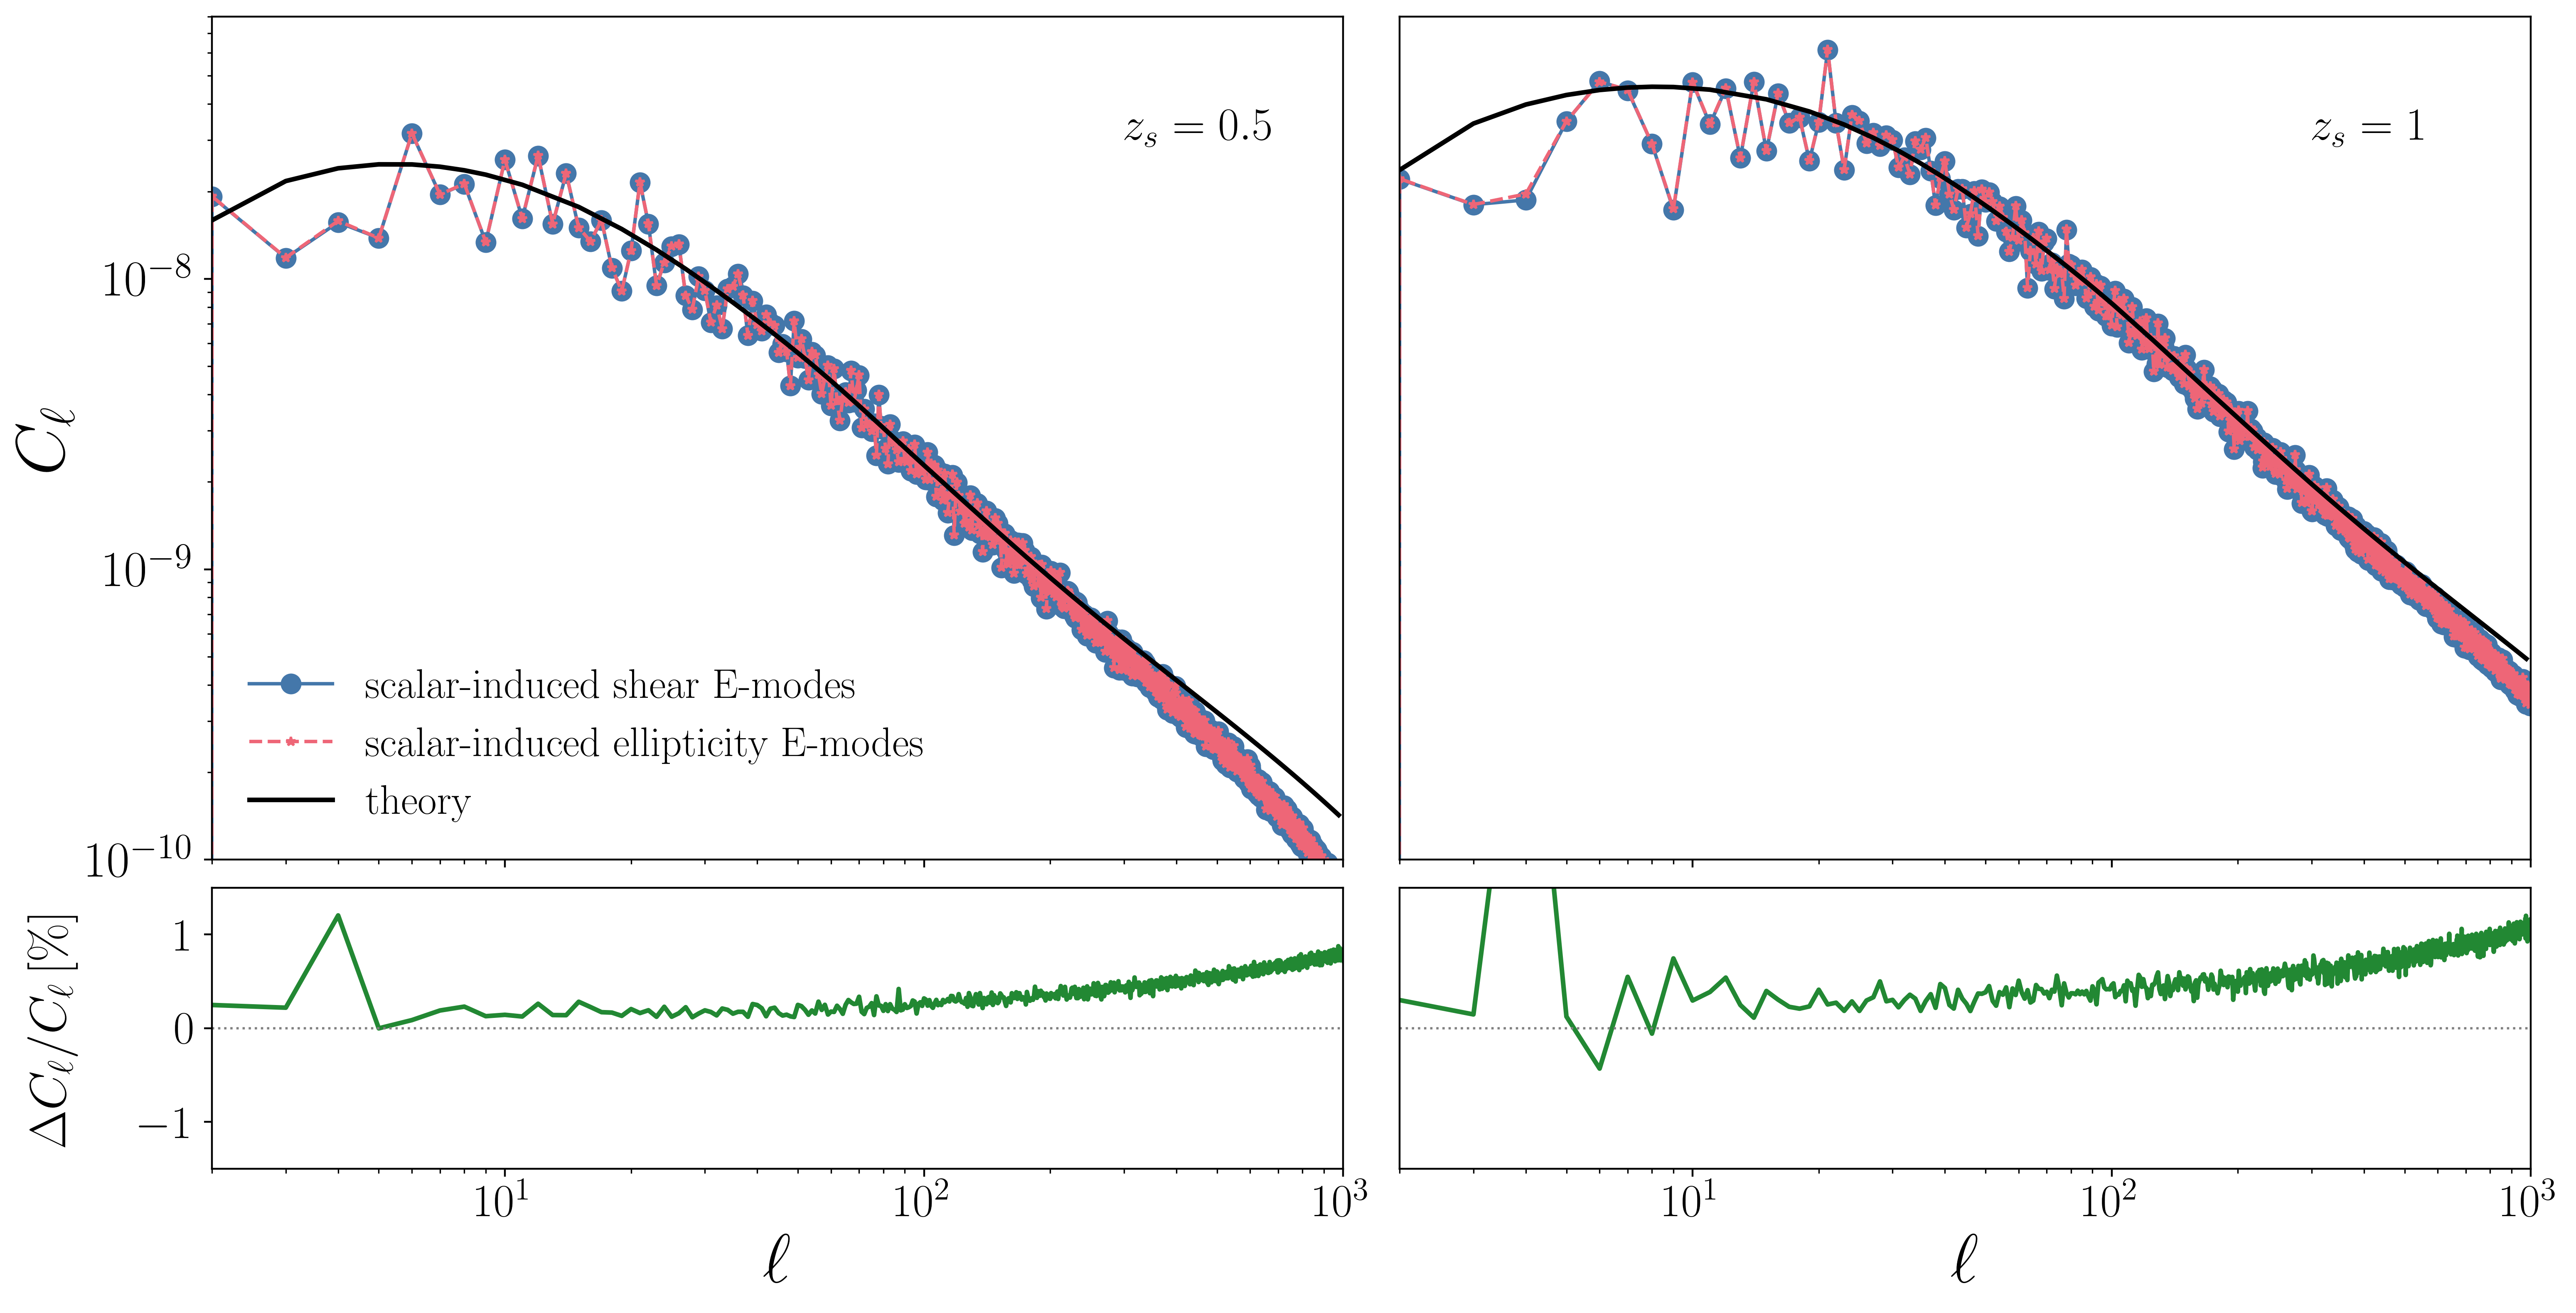

done


In [16]:
"""
Read ellipticity B-mode integrals from file. 
These integrals are time-consuming to compute, so we precompute them and read them from file for the final plots.
They are precomputed using the separate notebook 'shearBmodes-theory.ipynb'.
"""

path = 'theory/integrals_shearB/'
filename = path + 'integrals_epsBmodes_terms_z05_sim.npz'

data = np.load(filename)

l = data['l']

cl_eps_main = data['int_eps_main']
cl_eps_crossrot = data['int_eps_crossrot']
cl_eps_corr1 = data['int_eps_corr1']
cl_eps_corr2 = data['int_eps_corr2']
cl_eps_corr3 = data['int_eps_corr3']

sum_correction_eps = data['sum_correction']

path = 'theory/integrals_shearB/'
filename = path + 'integrals_epsBmodes_terms_z1_sim.npz'

data = np.load(filename)

l = data['l']

cl_eps_main_z1 = data['int_eps_main']
cl_eps_crossrot_z1 = data['int_eps_crossrot']
cl_eps_corr1_z1 = data['int_eps_corr1']
cl_eps_corr2_z1 = data['int_eps_corr2']
cl_eps_corr3_z1 = data['int_eps_corr3']

sum_correction_eps_z1 = data['sum_correction']

# =========================================================
# Fig. 7
# =========================================================

fig = plt.figure(figsize=(18, 9))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0.05,
    wspace=0.05
)


# ---- Top left
ax11 = fig.add_subplot(gs[0, 0])

ax11.plot(ell_noB, spectra[0.5]['cl_shear1_noB'],
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced shear E-modes')

ax11.plot(ell_noB, spectra[0.5]['cl_eps1_noB'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1], ls = '--',
          ms=4, label=r'scalar-induced ellipticity E-modes')

ax11.plot(lsamp_vec, cl_gammaE,
          ls='-', lw=2, color='k',
          label=r'theory')


ax11.set_xscale('log')
ax11.set_yscale('log')
ax11.set_ylim([1e-10, 8e-8])
ax11.set_xlim([2, 1000])

ax11.set_ylabel(r'$C_{\ell}$', fontsize=30)
ax11.legend(loc="lower left", fontsize=18, frameon=False)

ax11.tick_params(axis='y', labelsize=22)
ax11.tick_params(axis='x', labelbottom=False)

ax11.text(300, 3e-8, r'$z_s = 0.5$', fontsize=20)

# ---- Bottom left
ax21 = fig.add_subplot(gs[1, 0], sharex=ax11)

reldiff_z05 = (spectra[0.5]['cl_eps1_noB'][2:] - spectra[0.5]['cl_shear1_noB'][2:]) / (spectra[0.5]['cl_eps1_noB'][2:])


ax21.plot(ell_noB[2:], 100.0*reldiff_z05,
          ls='-', color=list(cset)[2], lw=2),

ax21.axhline(0.0, color='gray', ls=':', lw=1)

ax21.set_xscale('log')
ax21.set_xlim([2, 1000])
ax21.set_ylim([-1.5, 1.5])

ax21.set_ylabel(r'$\Delta C_{\ell} / C_{\ell}\,[\%]$', fontsize=22)
ax21.set_xlabel(r'$\ell$', fontsize=30)

ax21.tick_params(axis='both', labelsize=20)
#ax21.legend(loc="lower left", fontsize=16, ncol=2, frameon=False)

# ---- Top right
ax12 = fig.add_subplot(gs[0, 1])

ax12.plot(ell_noB, spectra[1.0]['cl_shear1_noB'],
          marker='o', mfc=list(cset)[0], color=list(cset)[0],
          ms=8, label=r'scalar-induced shear E-modes')

ax12.plot(ell_noB, spectra[1.0]['cl_eps1_noB'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1], ls = '--',
          ms=4, label=r'scalar-induced ellipticity E-modes')

ax12.plot(lsamp_vec, cl_gammaE_z1,
          ls='-', lw=2, color='k',
          label=r'theory')

ax12.text(300, 3e-8, r'$z_s = 1$', fontsize=20)


ax12.set_xscale('log')
ax12.set_yscale('log')
ax12.set_ylim([1.0e-10, 8e-8])
ax12.set_xlim([2, 1000])

ax12.tick_params(axis='y', which='both', left=False, labelleft=False)
ax12.tick_params(axis='x', labelbottom=False)

# ---- Bottom right
ax22 = fig.add_subplot(gs[1, 1], sharex=ax12)

reldiff_z1 = (spectra[1.0]['cl_eps1_noB'][2:] - spectra[1.0]['cl_shear1_noB'][2:]) / (spectra[1.0]['cl_eps1_noB'][2:])


ax22.plot(ell_noB[2:], 100.0*reldiff_z1,
          ls='-', color=list(cset)[2], lw=2),
 


ax22.axhline(0.0, color='gray', ls=':', lw=1)
ax22.tick_params(axis='y', which='both', left=False, labelleft=False)

ax22.set_xscale('log')
ax22.set_xlim([2, 1000])
ax22.set_ylim([-1.5, 1.5])

ax22.set_xlabel(r'$\ell$', fontsize=30)
ax22.tick_params(axis='both', labelsize=20)

fig.align_ylabels([ax11, ax21])
fig.align_ylabels([ax12, ax22])

plt.show()
#plt.savefig("Figures/scalar_ellipticity_Emodes.pdf", bbox_inches="tight")
plt.close(fig)

print("done")

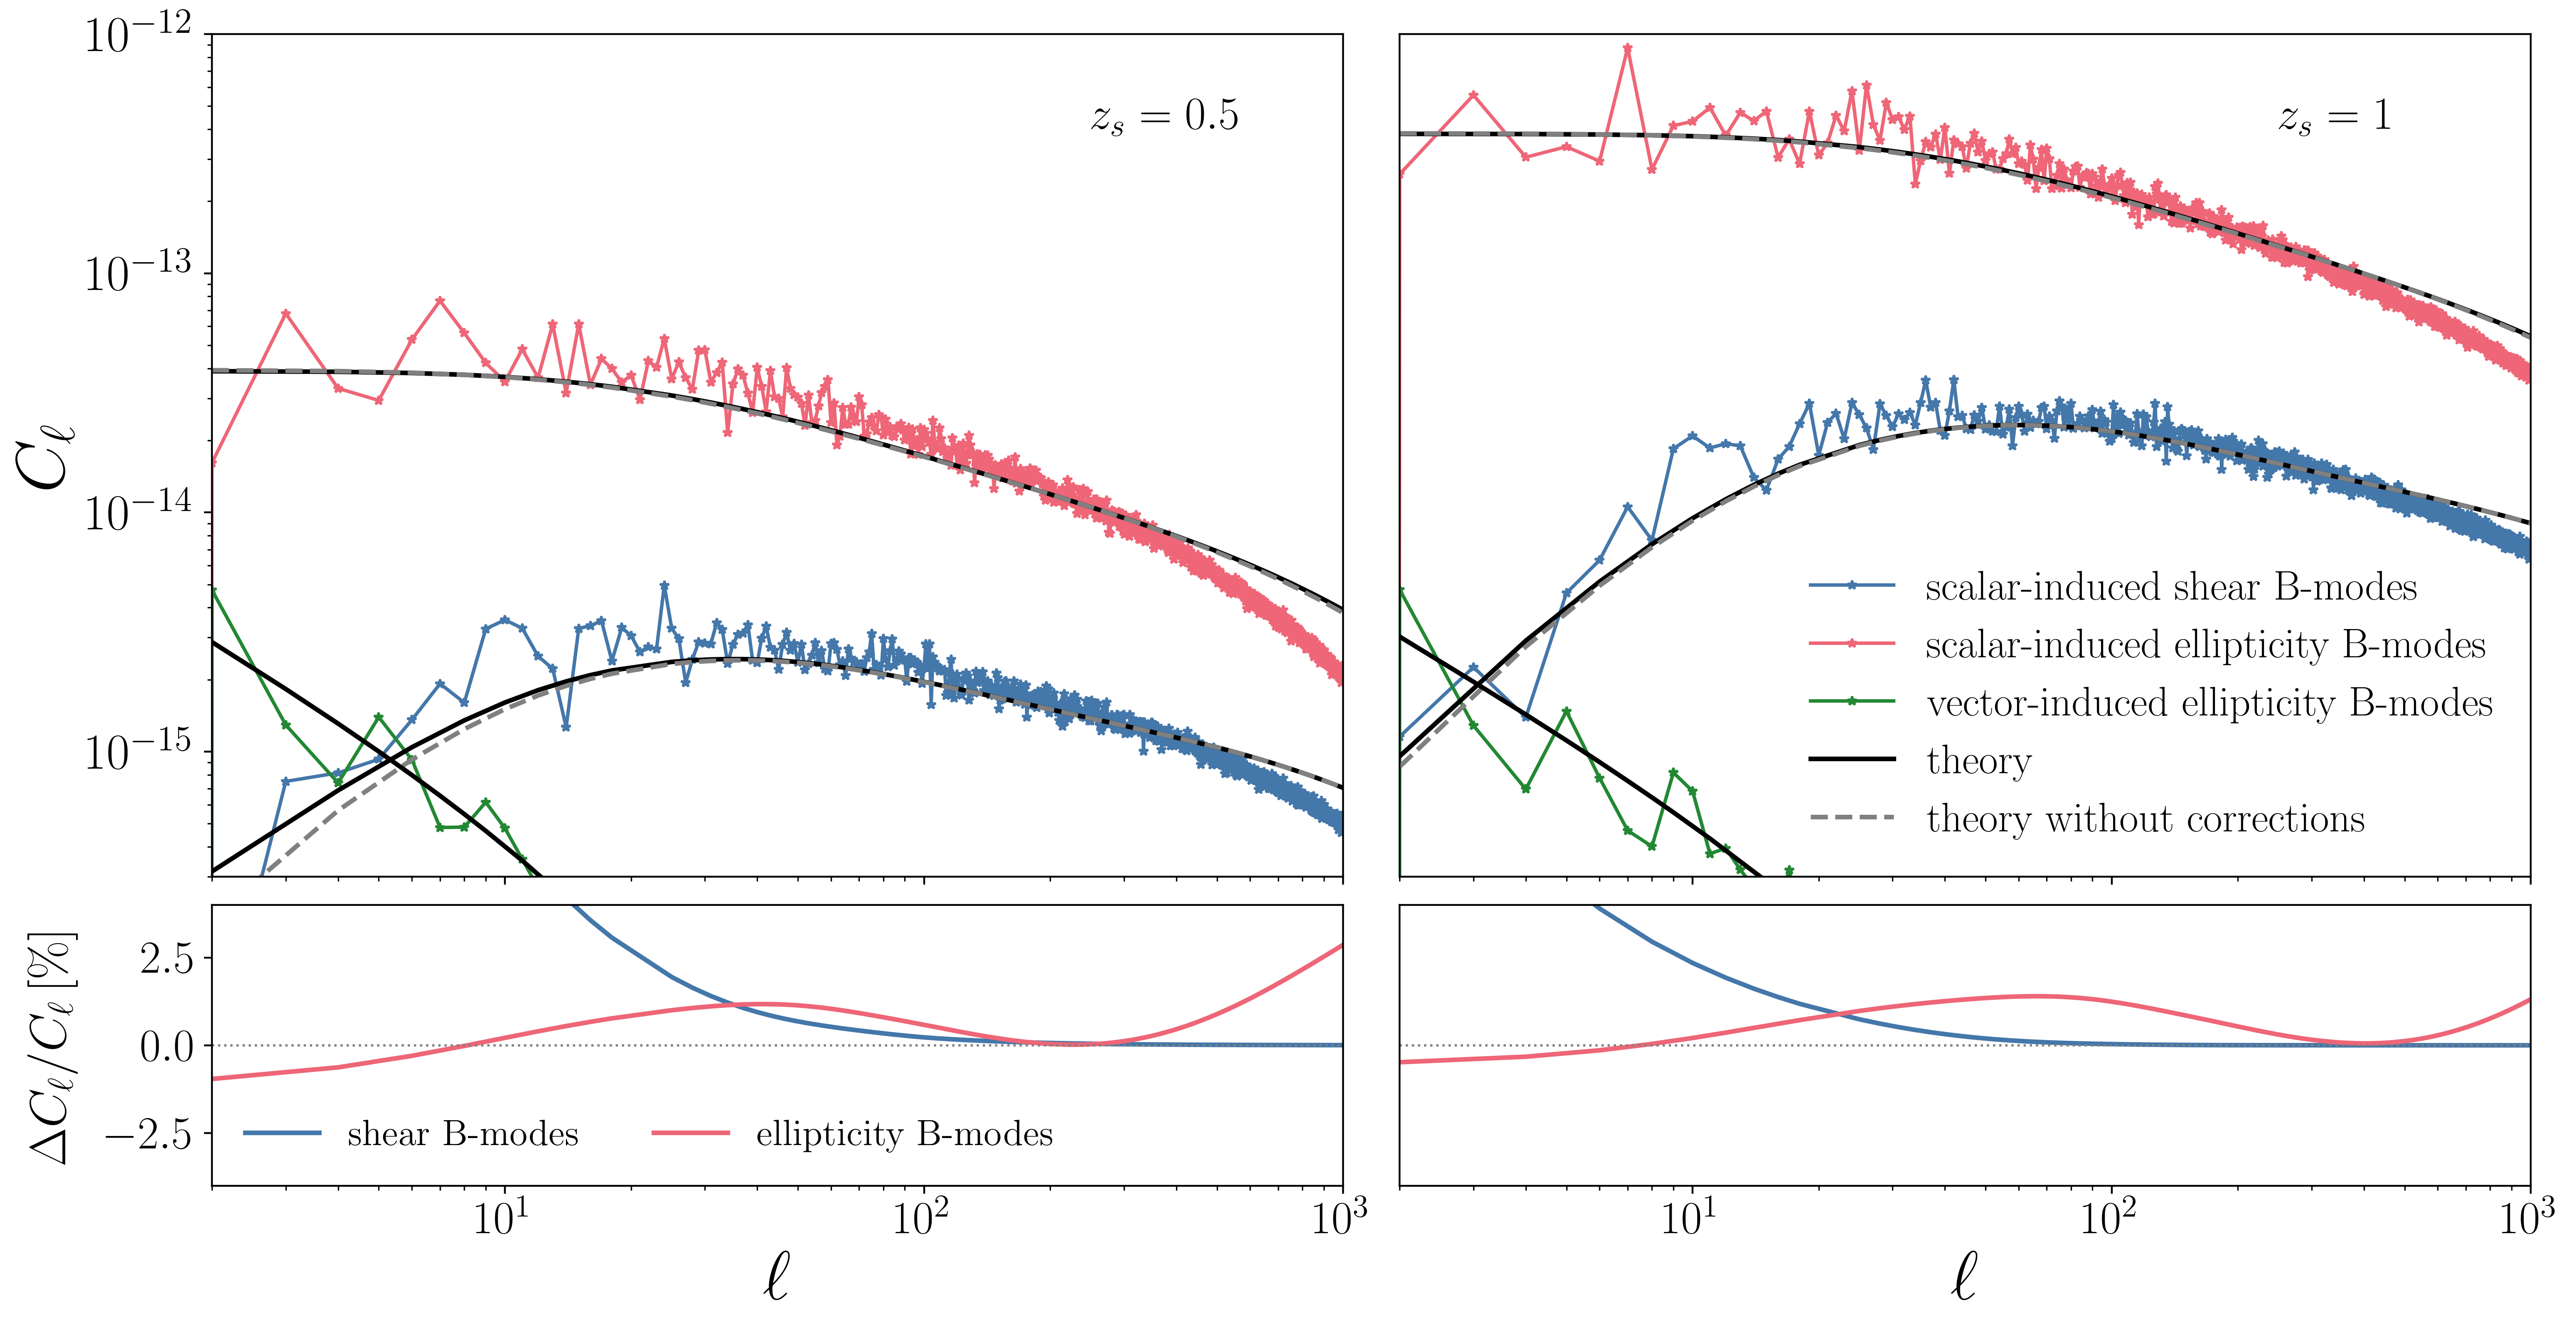

done


In [17]:
# =========================================================
# Fig. 8
# =========================================================

fig = plt.figure(figsize=(18, 9))

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0.05,
    wspace=0.05
)


# ---- Top left
ax11 = fig.add_subplot(gs[0, 0])

ax11.plot(ell_noB, spectra[0.5]['cl_shear2_noB'],
          marker='*', mfc=list(cset)[0], color=list(cset)[0],
          ms=4, label=r'scalar-induced shear B-modes')

ax11.plot(ell_noB, spectra[0.5]['cl_eps2_noB'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced ellipticity B-modes')

ax11.plot(ell_B, spectra[0.5]['cl_eps2_B'],
          marker='*', mfc=list(cset)[2], color=list(cset)[2],
          ms=4, label=r'vector-induced ellipticity B-modes')


ax11.plot(l, cl_omom + sum_corrections,
          ls='-', lw=2, color='k',
          label=r'theory')

ax11.plot(l, cl_omom,
          ls='--', lw=2, color='grey', label=r'theory without corrections')

ax11.plot(l, cl_omom + sum_corrections + sum_correction_eps,
          ls='-', lw=2, color='k')

ax11.plot(lsamp_vec, cl_shear_vector_z05,
          ls='-', lw=2, color='k')

ax11.plot(l, cl_omom + cl_eps_main,
          ls='--', lw=2, color='grey')

ax11.set_xscale('log')
ax11.set_yscale('log')
ax11.set_ylim([3e-16, 1.0e-12])
ax11.set_xlim([2, 1000])

ax11.set_ylabel(r'$C_{\ell}$', fontsize=30)

ax11.tick_params(axis='y', labelsize=22)
ax11.tick_params(axis='x', labelbottom=False)

ax11.text(250, 4e-13, r'$z_s = 0.5$', fontsize=20)

# ---- Bottom left
ax21 = fig.add_subplot(gs[1, 0], sharex=ax11)

reldiff_theory_shear = sum_corrections / (cl_omom + sum_corrections)
reldiff_theory_eps =  (sum_corrections + sum_correction_eps - cl_eps_main) / (cl_omom + sum_corrections + sum_correction_eps)


ax21.plot(l, 100.0*reldiff_theory_shear,
          ls='-', color=list(cset)[0], lw=2,
          label=r'shear B-modes')

ax21.plot(l, 100.0*reldiff_theory_eps,
          ls='-', color=list(cset)[1], lw=2,
          label=r'ellipticity B-modes')

ax21.axhline(0.0, color='gray', ls=':', lw=1)

ax21.set_xscale('log')
ax21.set_xlim([2, 1000])
ax21.set_ylim([-4.0, 4.0])

ax21.set_ylabel(r'$\Delta C_{\ell} / C_{\ell}\,[\%]$', fontsize=22)
ax21.set_xlabel(r'$\ell$', fontsize=30)

ax21.tick_params(axis='both', labelsize=20)
ax21.legend(loc="lower left", fontsize=16, ncol=2, frameon=False)

# ---- Top right
ax12 = fig.add_subplot(gs[0, 1])

ax12.plot(ell_noB, spectra[1.0]['cl_shear2_noB'],
          marker='*', mfc=list(cset)[0], color=list(cset)[0],
          ms=4, label=r'scalar-induced shear B-modes')

ax12.plot(ell_noB, spectra[1.0]['cl_eps2_noB'],
          marker='*', mfc=list(cset)[1], color=list(cset)[1],
          ms=4, label=r'scalar-induced ellipticity B-modes')

ax12.plot(ell_B, spectra[1.0]['cl_eps2_B'],
          marker='*', mfc=list(cset)[2], color=list(cset)[2],
          ms=4, label=r'vector-induced ellipticity B-modes')

ax12.plot(l_z1, cl_omom_z1 + sum_corrections_z1,
          ls='-', lw=2, color='k',
          label=r'theory')

ax12 .plot(l_z1, cl_omom_z1,
          ls='--', lw=2, color='grey', label=r'theory without corrections')

ax12.plot(l_z1, cl_omom_z1 + sum_corrections_z1 + sum_correction_eps_z1,
          ls='-', lw=2, color='k')#,

ax12.plot(lsamp_vec, cl_shear_vector_z1,
          ls='-', lw=2, color='k')#,

ax12.plot(l_z1, cl_omom_z1 + cl_eps_main_z1,
          ls='--', lw=2, color='grey')

ax12.text(250, 4e-13, r'$z_s = 1$', fontsize=20)

ax12.set_xscale('log')
ax12.set_yscale('log')
ax12.set_ylim([3e-16, 1.0e-12])
ax12.set_xlim([2, 1000])

ax12.tick_params(axis='y', which='both', left=False, labelleft=False)
ax12.tick_params(axis='x', labelbottom=False)

ax12.legend(loc="lower right", fontsize=18, ncol=1, frameon=False)

# ---- Bottom right
ax22 = fig.add_subplot(gs[1, 1], sharex=ax12)

reldiff_theory_shear_z1 = sum_corrections_z1 / (cl_omom_z1 + sum_corrections_z1)
reldiff_theory_eps_z1 =  (sum_corrections_z1 + sum_correction_eps_z1 - cl_eps_main_z1) / (cl_omom_z1 + sum_corrections_z1 + sum_correction_eps_z1)


ax22.plot(l, 100.0*reldiff_theory_shear_z1,
          ls='-', color=list(cset)[0], lw=2,
          label=r'shear B-modes')

ax22.plot(l, 100.0*reldiff_theory_eps_z1,
          ls='-', color=list(cset)[1], lw=2,
          label=r'ellipticity B-modes')

ax22.axhline(0.0, color='gray', ls=':', lw=1)
ax22.tick_params(axis='y', which='both', left=False, labelleft=False)

ax22.set_xscale('log')
ax22.set_xlim([2, 1000])
ax22.set_ylim([-4.0, 4.0])

ax22.set_xlabel(r'$\ell$', fontsize=30)
ax22.tick_params(axis='both', labelsize=20)

# =========================================================
# Final alignment
# =========================================================

fig.align_ylabels([ax11, ax21])
fig.align_ylabels([ax12, ax22])

plt.show()
#plt.savefig("Figures/scalar_ellipticity_with_vec.pdf", bbox_inches="tight")
plt.close(fig)

print("done")

# Fourier-space power spectra of metric perturbations

In [18]:
#Set up a new set of parameters for CAMB
pars = camb.CAMBparams()
A_s = 2.215e-9
n_s = 0.9619
h = 0.67
Omega_b = 0.049
Omega_cdm = 0.268580851704
T_cmb = 2.7255
N_ncdm = 2
N_ur = 1.01533

pars.set_cosmology(H0=100.0*h, ombh2=Omega_b*h*h, omch2=Omega_cdm*h*h, TCMB = T_cmb, omk=0, tau=0.06)
camb.set_params(num_nu_massless = 1.01533, num_nu_massive = 2, nu_mass_eigenstates = 2, nu_mass_degeneracies = [1, 1], nu_mass_numbers = [1, 1], nu_mass_fractions = [0.1481, 0.8519], share_delta_neff = True) 
pars.InitPower.set_params(As=A_s, ns=n_s, r=0)
pars.set_for_lmax(3500, lens_potential_accuracy=0);

z_source = 0.25
results = camb.get_background(pars)

k_values = np.logspace(-4, 2.0, 100, endpoint=True)

print('Start computation for vector potential:')
start = time.time()
DeltaB_theory_z025 = compute_DeltaB_spectrum(k_values, z_source)
elapsed = time.time() - start
print(f"Computation finished in {elapsed:.2f} seconds")

Start computation for vector potential:
Computation finished in 131.19 seconds


In [21]:
"""
Fourier space dimensionless power spectrum of the tensor perturbations h.
It follows the same structure as the computation of DeltaB above.
"""

def precompute_transfers_h(z, k_min=1e-5, k_max=1e2, nk=2000):
    k_sample = np.logspace(np.log10(k_min), np.log10(k_max), nk)
    transfer = cosmo_class.get_transfer(z)
    k_vals = transfer['k (h/Mpc)']

    def interp_table(name):
        f = interp1d(k_vals, transfer[name], kind='cubic', fill_value='extrapolate')
        return f(k_sample)

    transfer_fast = {
        "k": k_sample,
        "phi": interp_table('phi'),
        "theta_cdm": interp_table('t_cdm'),
        "theta_b": interp_table('t_b')
    }
    return transfer_fast

def kernel_prefactor_h(w, u):
    return 8.0 * (0.25 * (1 + w**2 - u**2)**2 - w**2)**2

def integrand_u_h(u, w, k, z, T):
    eps = 1e-40
    Kw, Ku = k*w, k*u

    # interpolate transfers
    phi_w, phi_u = np.interp([Kw, Ku], T['k'], T['phi'])
    t_cdm_w, t_cdm_u = np.interp([Kw, Ku], T['k'], T['theta_cdm'])
    t_b_w, t_b_u = np.interp([Kw, Ku], T['k'], T['theta_b'])

    # density parameters 
    Oc, Ob = cosmo_class.Om_cdm(z), cosmo_class.Om_b(z)

    # bracket as in the formula
    vel_term = Oc*(t_cdm_w/h/(k**2*w**2+eps))*(t_cdm_u/h/(k**2*u**2+eps)) + Ob*(t_b_w/h/(k**2*w**2+eps))*(t_b_u/h/(k**2*u**2+eps))
    bracket = phi_w*phi_u + 1.5 * Hconf_z(z)**2 * vel_term

    val = bracket**2 * DeltaR(Kw) * DeltaR(Ku) * kernel_prefactor_h(w, u)

    return val / (w**2 * u**2 + eps)

def integrand_w_log_h(logw, k, z, T):
    w = np.exp(logw)
    umin, umax = abs(w-1.0), w+1.0
    res_u, _ = quad_vec(integrand_u_h, umin, umax, args=(w, k, z, T), epsabs=1e-8, epsrel=1e-5)
    return res_u * w  # Jacobian for d(log w)

def DeltaH(k, z, T, w_max=100.0):
    logw_min, logw_max = np.log(1e-5), np.log(w_max)
    result, _ = quad_vec(integrand_w_log_h, logw_min, logw_max, args=(k, z, T), epsabs=1e-8, epsrel=1e-4)
    return result

def compute_DeltaH_spectrum(k_values, z):
    DeltaH_values = np.zeros_like(k_values)
    T = precompute_transfers_h(z)

    for i, k in enumerate(k_values):
        DeltaH_values[i] = DeltaH(k, z, T)
    return DeltaH_values

z_source = 0.25
print('Start computation for tensor perturbations:')
start = time.time()
DeltaH_theory_z025 = compute_DeltaH_spectrum(k_values, z_source)
elapsed = time.time() - start
print(f"Computation finished in {elapsed:.2f} seconds")

Start computation for tensor perturbations:
Computation finished in 13.43 seconds


In [22]:
"""
Fourier space dimensionless linear power spectrum of the Weyl potential.
It uses CLASS to compute the linear matter power spectrum and then converts it to potential power spectrum via the Poisson equation.
"""
# k in units of h/Mpc
z_source = 0.25
P_delta = np.array([cosmo_class.pk(k_val*h, z_source)*h**3 for k_val in k_values])  # CLASS expects k in 1/Mpc
H0 = 100.0 * h  # km/s/Mpc
# Poisson equation to convert to potential power spectrum
# P_phi(k) = (3/2 * Omega_m * H0^2 / (a k^2))^2 * P_delta(k)
H0_Mpc = H0 / 2997.92458  # now H0 in 1/Mpc
a = 1.0/(1+z_source)
Omega_m = cosmo_class.Om_m(z_source)
prefactor = (1.5 * Omega_m * Hconf_z(z_source)**2/((k_values)**2))**2  
P_phi = prefactor * P_delta

#Convert to dimensionless power spectrum 
Delta_phi_z025 = k_values**3 * P_phi / (2.0 * np.pi**2)

"""
1-loop contribution to the Fourier space dimensionless power spectrum of the Weyl potential.
It reads CLASS-PT output from a file and converts it to potential power spectrum via the Poisson equation.
"""
# Load first two columns
path = 'theory/class-pt/'
data_classpt = np.loadtxt(path + "myfid_z2_pk_nl_pt.dat", usecols=(0, 1))

# Store into variables
ktest_1loop = data_classpt[:, 0]
Pdelta_1loop = data_classpt[:, 1]
prefactor_1loop = (1.5 * Omega_m * Hconf_z(z_source)**2/((ktest_1loop)**2))**2  
P_phi_1loop = prefactor_1loop * Pdelta_1loop
#Convert to Delta_phi
Delta_phi_1loop_z025 = ktest_1loop**3 * P_phi_1loop / (2.0 * np.pi**2)

print('Power spectrum of the Weyl potential at z = 0.25 computed.')

Power spectrum of the Weyl potential at z = 0.25 computed.


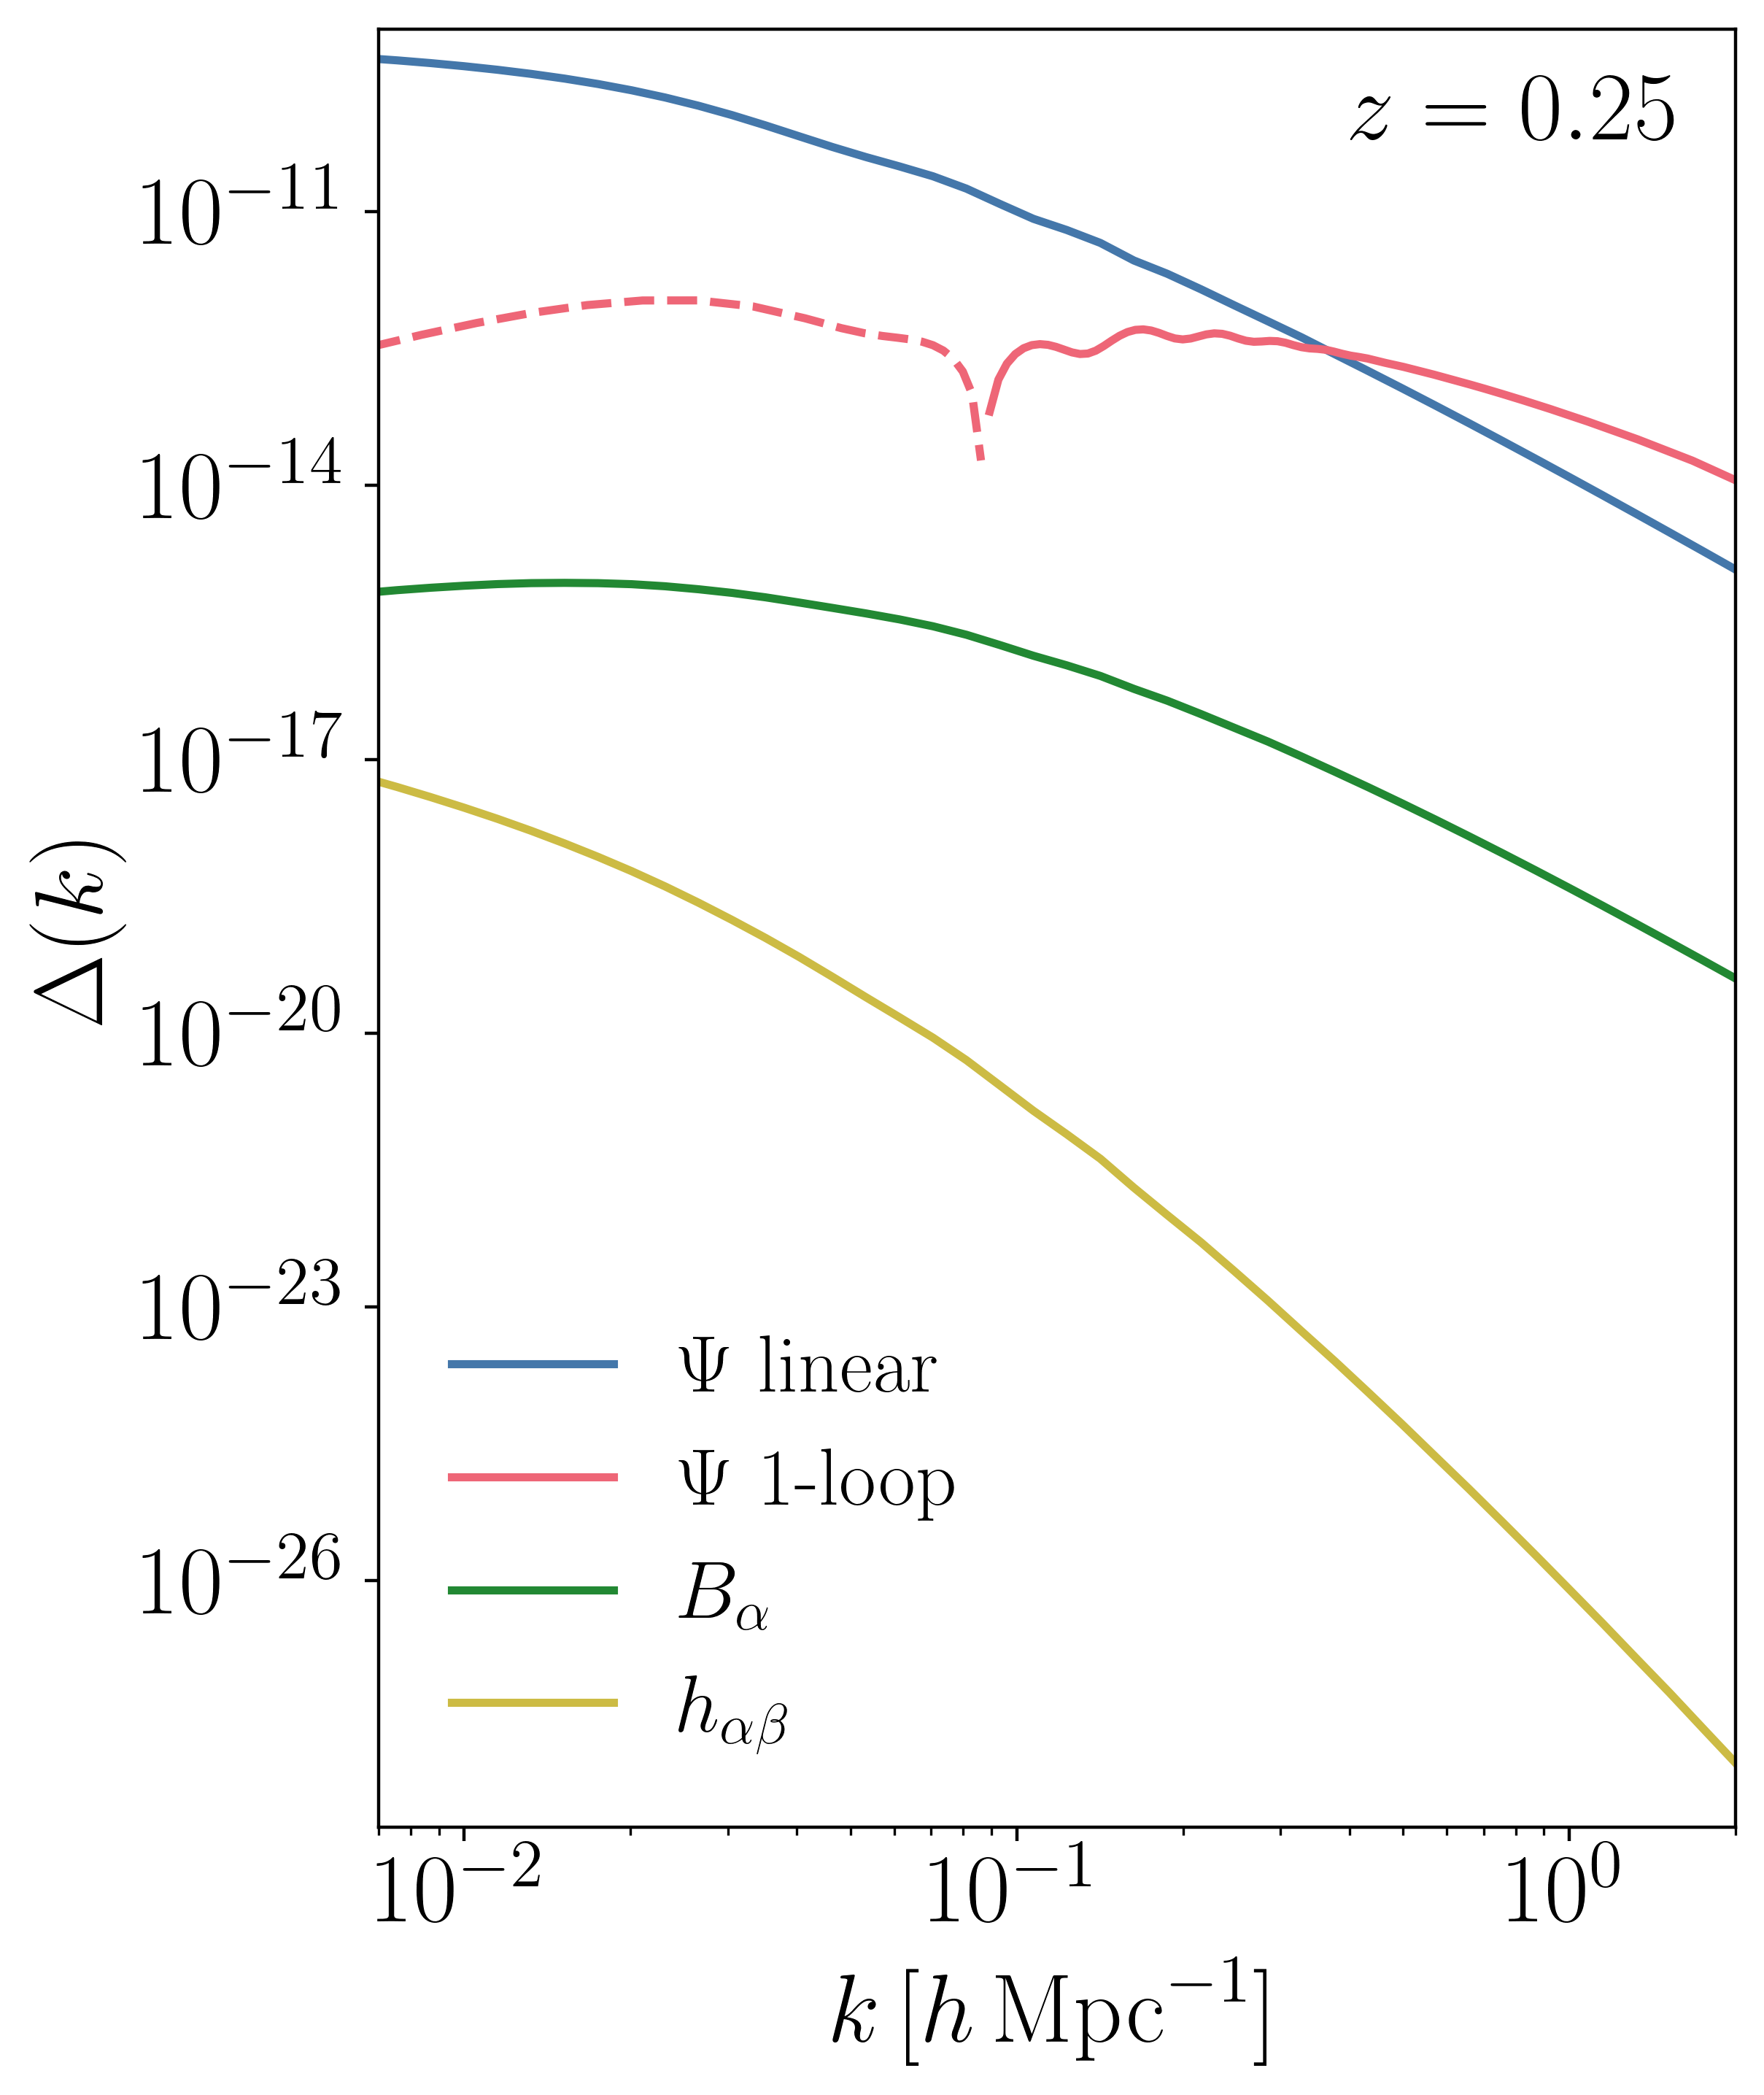

done


In [23]:
# =========================================================
# Fig. 1
# =========================================================

# Remove values of Delta_phi_1loop_z025 that are too close to zero
eps = 1e-40  

Delta_phi_pos = np.where(Delta_phi_1loop_z025 > eps,
                          Delta_phi_1loop_z025,
                          np.nan)

Delta_phi_neg = np.where(Delta_phi_1loop_z025 < -eps,
                          -Delta_phi_1loop_z025,
                          np.nan)

fig = plt.figure(figsize=(6,8))
ax1 = plt.subplot()

ax1.plot(k_values, Delta_phi_z025, color = list(cset)[0], lw = 2, ls = '-', label = r'$\Psi$ linear')
ax1.plot(ktest_1loop, Delta_phi_pos, color=list(cset)[1], lw=2, ls='-', label=r'$\Psi$ $1$-loop')
ax1.plot(ktest_1loop, Delta_phi_neg, color=list(cset)[1], lw=2, ls='--')
ax1.plot(k_values, DeltaB_theory_z025, color = list(cset)[2], lw = 2, ls = '-', label = r'$B_\alpha$')
ax1.plot(k_values, DeltaH_theory_z025, color = list(cset)[3], lw = 2, ls = '-', label = r'$h_{\alpha\beta}$')

plt.legend(loc = "lower left", fontsize = 20, frameon=False, ncol = 1)#, bbox_to_anchor=(1, 0.0))

plt.text(0.4, 6.0e-11, '$z = 0.25$', fontsize=24)
plt.ylabel('$\Delta(k)$', fontsize = 24)#; plt.grid()

plt.xscale('log')
plt.yscale('log')
plt.yticks(fontsize=24)

plt.yticks(fontsize=24)
plt.xticks(fontsize=24)#, rotation=90)

plt.xlabel('$k\,[h\,\mathrm{Mpc}^{-1}]$', fontsize = 24) 
plt.xlim(7.0e-3, 2.0)
pylab.ylim([2e-29, 1e-9])
#plt.savefig('Figures/Spectra_perturb_z025.pdf', format = "PDF", bbox_inches='tight', edgecolor="k", dpi = 300)
plt.show()
plt.close(fig)
print('done')